In [2]:
"""Cell 0: Imports and constants — run this first after any kernel restart"""

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────
CAMELS_DIR = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001'
SHP_PATH   = f'{CAMELS_DIR}/polygon/polygon.shp'
Q_PATH     = f'{CAMELS_DIR}/q_m3s_mon.csv'
NC_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET/WA1/run_output_2000_2019_hydro_TC_WA1.nc'
RGI_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

# ── Constants ─────────────────────────────────────────────────────────────
ICE_DENSITY   = 900     # kg/m³
WATER_DENSITY = 1000    # kg/m³

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Plot colors ───────────────────────────────────────────────────────────
C_Q     = '#2196F3'
C_IMBAL = '#FF5722'
C_MELT  = '#9C27B0'
C_FR    = '#4CAF50'

print('✓ Cell 0 complete — imports, paths, constants loaded')
print(f'  NC_PATH:  {NC_PATH}')
print(f'  Q_PATH:   {Q_PATH}')
print(f'  SHP_PATH: {SHP_PATH}')

✓ Cell 0 complete — imports, paths, constants loaded
  NC_PATH:  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET/WA1/run_output_2000_2019_hydro_TC_WA1.nc
  Q_PATH:   /Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001/q_m3s_mon.csv
  SHP_PATH: /Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001/polygon/polygon.shp


In [2]:
"""Cell 1: Spatial join — find RGI glaciers inside Allipen basin"""

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

# ── Paths ─────────────────────────────────────────────────────────────────
CAMELS_DIR = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001'
SHP_PATH   = f'{CAMELS_DIR}/polygon/polygon.shp'
Q_PATH     = f'{CAMELS_DIR}/q_m3s_mon.csv'
NC_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET/WA1/run_output_2000_2019_hydro_TC_WA1.nc'
RGI_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

ICE_DENSITY   = 900
WATER_DENSITY = 1000

# Load basin polygon
basin = gpd.read_file(SHP_PATH).to_crs('EPSG:4326')
basin_area_km2 = basin.to_crs('EPSG:32718').area.values[0] / 1e6
print(f'Basin area: {basin_area_km2:.1f} km²')

# Load RGI and do point-in-polygon join
rgi     = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi, geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat), crs='EPSG:4326')
glaciers_in_basin = gpd.sjoin(gdf_rgi, basin, how='inner', predicate='within')
rgi_ids = glaciers_in_basin['RGIId'].values

glacier_area = glaciers_in_basin['Area'].sum()
print(f'Glaciers in basin:  {len(rgi_ids)}')
print(f'Total glacier area: {glacier_area:.2f} km²  '
      f'({glacier_area / basin_area_km2 * 100:.1f}% of basin)')

Basin area: 830.4 km²
Glaciers in basin:  92
Total glacier area: 35.56 km²  (4.3% of basin)


In [3]:
"""Cell 2 FIXED: Extract annual volume loss — fix time coordinate parsing"""

ds   = xr.open_dataset(NC_PATH)
mask = np.isin(ds['rgi_id'].values, rgi_ids)
print(f'Matched {mask.sum()} / {len(rgi_ids)} glaciers in NetCDF')

# Diagnose the time coordinate
print(f'\nRaw time values: {ds["time"].values}')
print(f'Time dtype: {ds["time"].dtype}')
print(f'Time attrs: {ds["time"].attrs}')

# OGGM stores time as integer years (e.g. 2000, 2001...) not datetime
# Extract directly as integers
time_vals = ds['time'].values
print(f'\nTime values as-is: {time_vals}')

# If they're already integers like 2000-2019, use directly
# If they decoded wrongly, cast to int
years = time_vals.astype(int)
print(f'Years: {years}')

# Annual volume summed across basin glaciers
vol        = ds['volume'].sel(rgi_id=ds['rgi_id'][mask]).sum(dim='rgi_id')
vol_series = pd.Series(vol.values, index=years, name='volume_m3_ice')

print(f'\nVolume series:')
print(vol_series)

# Δvolume → water (positive = ice loss released to runoff)
dvol_annual   = vol_series.diff().shift(-1)   # ← add .shift(-1)
dwater_annual = (-dvol_annual * (ICE_DENSITY / WATER_DENSITY)).clip(lower=0)
dwater_annual.name = 'glacier_water_m3'

print(f'\nMean annual ice loss → water: {dwater_annual.mean():.2e} m³/yr')
print(f'\nFull annual series:')
print(dwater_annual.dropna().to_string())

Matched 92 / 92 glaciers in NetCDF

Raw time values: [1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010.
 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022.]
Time dtype: float64
Time attrs: {'description': 'Floating hydrological year'}

Time values as-is: [1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010.
 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022.]
Years: [1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]

Volume series:
1999    2.509964e+09
2000    2.479768e+09
2001    2.489191e+09
2002    2.471003e+09
2003    2.463325e+09
2004    2.439903e+09
2005    2.402524e+09
2006    2.418851e+09
2007    2.415346e+09
2008    2.377977e+09
2009    2.331064e+09
2010    2.313969e+09
2011    2.283623e+09
2012    2.240386e+09
2013    2.185672e+09
2014    2.137098e+09
2015    2.115194e+09
2016    2.089262e+09
2017    2.009015e+09
2018    1.

In [4]:
"""Cell 3: Extract total ablation flux (melt_on_glacier_monthly)
   Units: kg → m³ water (divide by water density)
   Note: this is the total ablation flux, NOT net volume change.
   melt_on_glacier >> Δvolume because accumulation replenishes much of
   what melts — the glacier storage barely changes even though significant
   melt water flows through it seasonally.
"""

melt_2d = ds['melt_on_glacier_monthly'].sel(
    rgi_id=ds['rgi_id'][mask]).sum(dim='rgi_id')  # shape: (24 years, 12 months)

# Build (years × 12) DataFrame then stack to monthly series
melt_df = pd.DataFrame(melt_2d.values, index=years, columns=range(1, 13))
melt_monthly = melt_df.stack()
melt_monthly.index = pd.to_datetime(
    [f'{y}-{m:02d}-01' for y, m in melt_monthly.index])
melt_monthly = melt_monthly.sort_index()

# Convert kg → m³ water
melt_monthly = melt_monthly / WATER_DENSITY
melt_monthly.name = 'melt_on_glacier_m3'

# Annual sum
melt_annual = melt_monthly.resample('YE').sum()
melt_annual.index = melt_annual.index.year

print('Sanity check:')
print(f'  Mean annual ablation flux (m³/yr):  {melt_annual.mean():.2e}  ← total melt')
print(f'  Mean annual Δvolume→water (m³/yr):  {dwater_annual.mean():.2e}  ← net ice loss')
print(f'  Ablation / Δvolume ratio:           {melt_annual.mean() / dwater_annual.mean():.1f}x')
print(f'  → accumulation offsets ~{(1 - dwater_annual.mean()/melt_annual.mean())*100:.0f}% of annual melt in this basin')
print(f'\n✓ Run Cell 4 next, then Cell 5 for fractions vs Q')

Sanity check:
  Mean annual ablation flux (m³/yr):  9.31e+07  ← total melt
  Mean annual Δvolume→water (m³/yr):  2.98e+07  ← net ice loss
  Ablation / Δvolume ratio:           3.1x
  → accumulation offsets ~68% of annual melt in this basin

✓ Run Cell 4 next, then Cell 5 for fractions vs Q


In [5]:
"""Cell 4: Load CAMELS Q, convert m³/s → m³/month and m³/yr"""

q_raw = pd.read_csv(Q_PATH)
q_raw['date'] = pd.to_datetime(q_raw['date'])
q_raw = q_raw.set_index('date')
q_m3s = q_raw['9402001']

# m³/s → m³/month
q_m3_month = (q_m3s * q_m3s.index.days_in_month * 86400).dropna()

# Annual totals
q_annual = q_m3_month.resample('YE').sum()
q_annual.index = q_annual.index.year

print(f'Q period: {q_m3_month.index.min().date()} to {q_m3_month.index.max().date()}')
print(f'Mean annual Q: {q_annual.mean():.2e} m³/yr')
print(f'\nAnnual Q series:')
print(q_annual.to_string())

Q period: 1985-01-01 to 2019-02-01
Mean annual Q: 2.04e+09 m³/yr

Annual Q series:
date
1985    2.417108e+09
1986    2.599969e+09
1987    2.113021e+09
1988    1.778724e+09
1989    1.818091e+09
1990    2.455177e+09
1991    2.202663e+09
1992    2.471404e+09
1993    3.339808e+09
1994    2.862193e+09
1995    2.798149e+09
1996    1.801950e+09
1997    2.430192e+09
1998    1.445100e+09
1999    1.569100e+09
2000    2.189172e+09
2001    2.600601e+09
2002    2.526361e+09
2003    2.309311e+09
2004    2.331715e+09
2005    2.576785e+09
2006    1.339170e+09
2007    1.755488e+09
2008    2.274393e+09
2009    2.594065e+09
2010    1.932690e+09
2011    1.985135e+09
2012    1.933805e+09
2013    1.771271e+09
2014    2.004269e+09
2015    1.548720e+09
2016    9.194605e+08
2017    4.475956e+08
2018    2.086493e+09
2019    2.845398e+08


In [6]:
"""Cell 5: Align timeseries and compute glacier contribution (annual + monthly)
   Two metrics reported:
   - Ablation contribution:    total melt flux / Q  (~7% — includes melt replenished by accumulation)
   - Imbalance contribution:   net ice loss (Δvolume → water) / Q  (~2.5% — non-renewable, unsustainable)
   The difference between the two is melt that is recycled — melted in summer, replenished by winter snowfall.
"""

# ── Annual ────────────────────────────────────────────────────────────────
common_years = (dwater_annual.dropna().index.intersection(q_annual.index))
common_years = common_years[(common_years >= 2000) & (common_years <= 2019)]

q_ann      = q_annual.loc[common_years]
gl_imbal   = dwater_annual.loc[common_years]    # net ice loss → water
gl_melt    = melt_annual.loc[common_years]      # total ablation flux → water

frac_imbal = (gl_imbal / q_ann * 100).clip(0, 100)
frac_melt  = (gl_melt  / q_ann * 100).clip(0, 100)

print(f'Common years: {common_years[0]}–{common_years[-1]}')
print(f'\nMean annual Q:                         {q_ann.mean():.2e} m³/yr')
print(f'\nAblation contribution (total melt):')
print(f'  Mean: {frac_melt.mean():.1f}%   Max: {frac_melt.max():.1f}% (year {frac_melt.idxmax()})')
print(f'\nImbalance contribution (net ice loss):')
print(f'  Mean: {frac_imbal.mean():.1f}%   Max: {frac_imbal.max():.1f}% (year {frac_imbal.idxmax()})')

# ── Monthly ───────────────────────────────────────────────────────────────
start, end = f'{common_years[0]}-01-01', f'{common_years[-1]}-12-31'
q_mon      = q_m3_month.loc[start:end]
gl_mon     = melt_monthly.loc[start:end]
common_mon = q_mon.index.intersection(gl_mon.index)
q_mon_c    = q_mon.loc[common_mon]
gl_mon_c   = gl_mon.loc[common_mon]

frac_melt_mon = (gl_mon_c / q_mon_c * 100).clip(0, 100)

# Seasonal means
gl_seasonal  = frac_melt_mon.groupby(frac_melt_mon.index.month).mean()
q_seasonal   = q_mon_c.groupby(q_mon_c.index.month).mean()
gl_mon_mean  = gl_mon_c.groupby(gl_mon_c.index.month).mean()

print(f'\nMonthly ablation contribution:')
print(f'  Mean: {frac_melt_mon.mean():.1f}%')
print(f'  Peak month: {MONTH_NAMES[gl_seasonal.idxmax()-1]} ({gl_seasonal.max():.1f}%)')

Common years: 2000–2019

Mean annual Q:                         1.87e+09 m³/yr

Ablation contribution (total melt):
  Mean: 7.3%   Max: 33.2% (year 2019)

Imbalance contribution (net ice loss):
  Mean: 2.3%   Max: 11.5% (year 2019)

Monthly ablation contribution:
  Mean: 5.9%
  Peak month: Feb (17.8%)


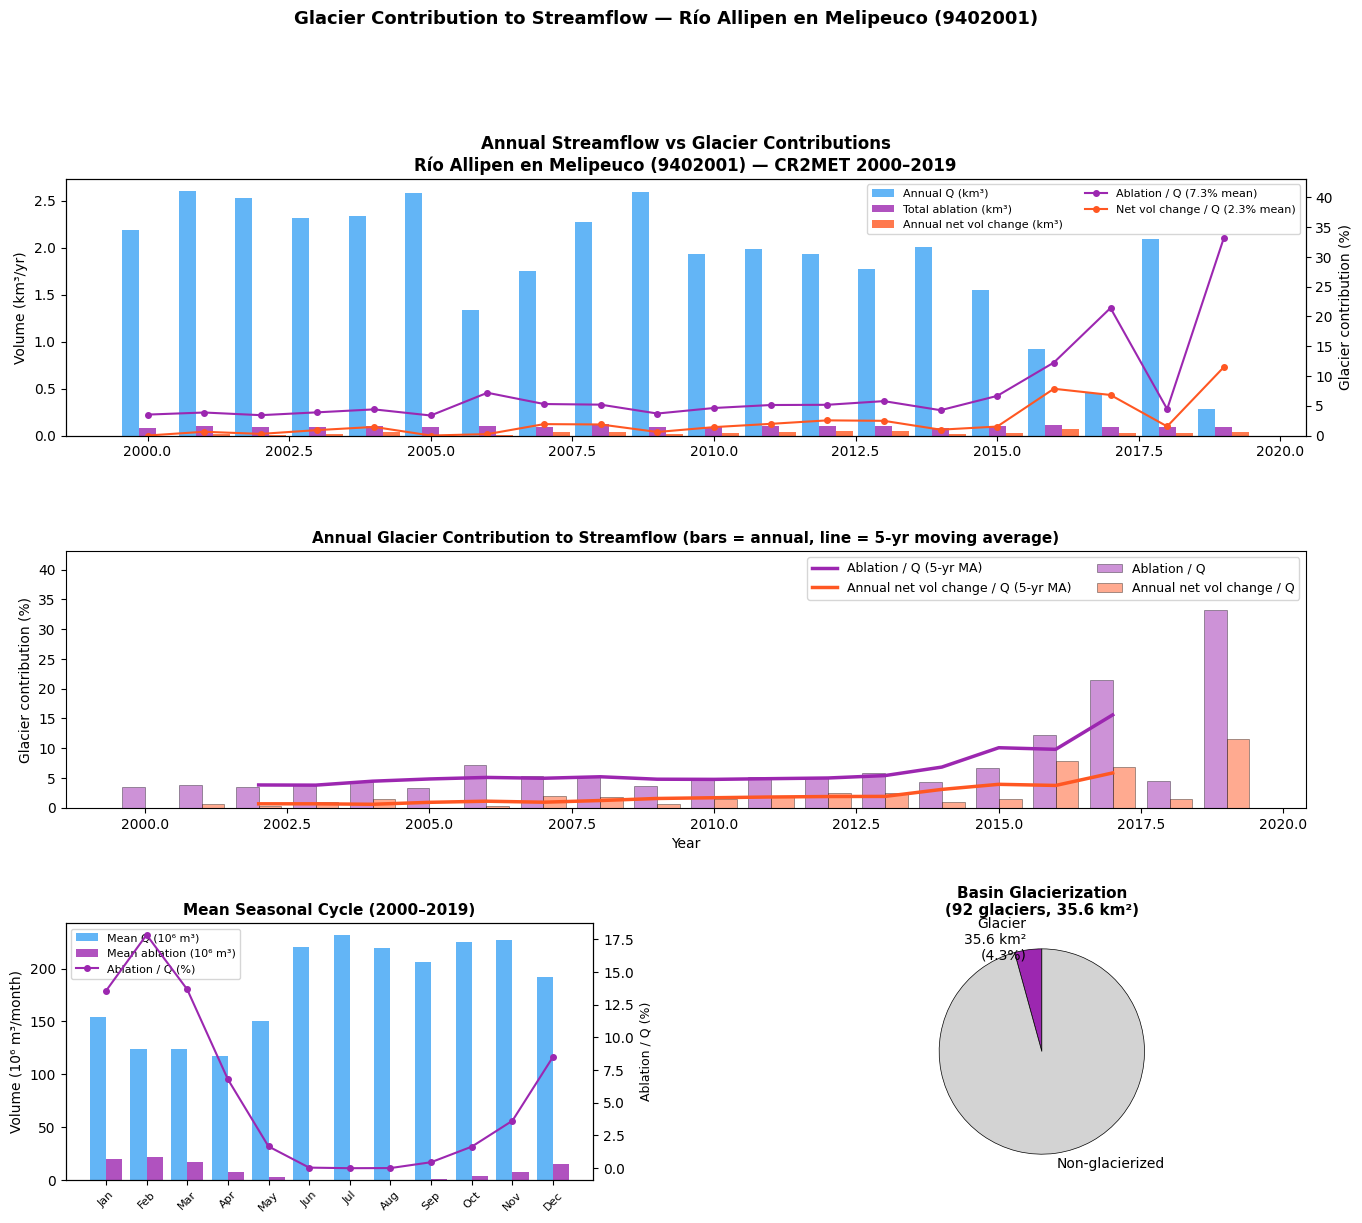

In [7]:
"""Cell 6: Plot annual + seasonal glacier contributions"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

C_Q      = '#2196F3'
C_IMBAL  = '#FF5722'   # net volume change
C_MELT   = '#9C27B0'   # total ablation
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Annual Q vs both glacier quantities ───────────────────────────
ax1  = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()

x = np.array(common_years, dtype=float)
ax1.bar(x - 0.3, q_ann    / 1e9, width=0.3, color=C_Q,     alpha=0.7, label='Annual Q (km³)')
ax1.bar(x,       gl_melt  / 1e9, width=0.3, color=C_MELT,  alpha=0.8, label='Total ablation (km³)')
ax1.bar(x + 0.3, gl_imbal / 1e9, width=0.3, color=C_IMBAL, alpha=0.8, label='Annual net vol change (km³)')
ax1b.plot(x, frac_melt.values,  '-o', color=C_MELT,  markersize=4, linewidth=1.5,
          label=f'Ablation / Q ({frac_melt.mean():.1f}% mean)')
ax1b.plot(x, frac_imbal.values, '-o', color=C_IMBAL, markersize=4, linewidth=1.5,
          label=f'Net vol change / Q ({frac_imbal.mean():.1f}% mean)')

ax1.set_ylabel('Volume (km³/yr)', fontsize=10)
ax1b.set_ylabel('Glacier contribution (%)', fontsize=10)
ax1b.set_ylim(0, max(frac_melt.max() * 1.3, 10))
ax1.set_title('Annual Streamflow vs Glacier Contributions\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right', ncol=2)

# ── Panel 2: Annual fractions with 5-yr moving average ────────────────────
ax2 = fig.add_subplot(gs[1, :])

# Bar charts
ax2.bar(x - 0.2, frac_melt.values,  width=0.4, color=C_MELT,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Ablation / Q')
ax2.bar(x + 0.2, frac_imbal.values, width=0.4, color=C_IMBAL,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Annual net vol change / Q')

# 5-year moving averages
ma_melt  = pd.Series(frac_melt.values,  index=x).rolling(5, center=True).mean()
ma_imbal = pd.Series(frac_imbal.values, index=x).rolling(5, center=True).mean()

ax2.plot(x, ma_melt.values,  '-', color=C_MELT,  linewidth=2.5,
         label='Ablation / Q (5-yr MA)')
ax2.plot(x, ma_imbal.values, '-', color=C_IMBAL, linewidth=2.5,
         label='Annual net vol change / Q (5-yr MA)')

ax2.set_ylabel('Glacier contribution (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, max(frac_melt.max() * 1.3, 5))
ax2.set_title('Annual Glacier Contribution to Streamflow (bars = annual, line = 5-yr moving average)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, ncol=2)

# ── Panel 3: Mean seasonal cycle ──────────────────────────────────────────
ax3  = fig.add_subplot(gs[2, 0])
ax3b = ax3.twinx()
ax3.bar(np.arange(1,13) - 0.2, q_seasonal  / 1e6, width=0.4,
        color=C_Q,    alpha=0.7, label='Mean Q (10⁶ m³)')
ax3.bar(np.arange(1,13) + 0.2, gl_mon_mean / 1e6, width=0.4,
        color=C_MELT, alpha=0.8, label='Mean ablation (10⁶ m³)')
ax3b.plot(range(1,13), gl_seasonal.values, '-o',
          color=C_MELT, markersize=4, linewidth=1.5, label='Ablation / Q (%)')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(MONTH_NAMES, fontsize=8, rotation=45)
ax3.set_ylabel('Volume (10⁶ m³/month)', fontsize=10)
ax3b.set_ylabel('Ablation / Q (%)', fontsize=9)
ax3.set_title('Mean Seasonal Cycle (2000–2019)', fontsize=11, fontweight='bold')
lines3, labs3 = ax3.get_legend_handles_labels()
lines4, labs4 = ax3b.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labs3 + labs4, fontsize=8)

# ── Panel 4: Basin glacierization pie ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
glacier_pct = glacier_area / basin_area_km2 * 100
sizes  = [glacier_area, basin_area_km2 - glacier_area]
labels = [f'Glacier\n{glacier_area:.1f} km²\n({glacier_pct:.1f}%)', 'Non-glacierized']
ax4.pie(sizes, labels=labels, colors=[C_MELT, 'lightgray'],
        startangle=90, wedgeprops=dict(edgecolor='black', linewidth=0.5))
ax4.set_title(f'Basin Glacierization\n({len(rgi_ids)} glaciers, {glacier_area:.1f} km²)',
              fontsize=11, fontweight='bold')

plt.suptitle('Glacier Contribution to Streamflow — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_glacier_contribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

## redoing per Ale's suggestion w fewer variables mapped: 

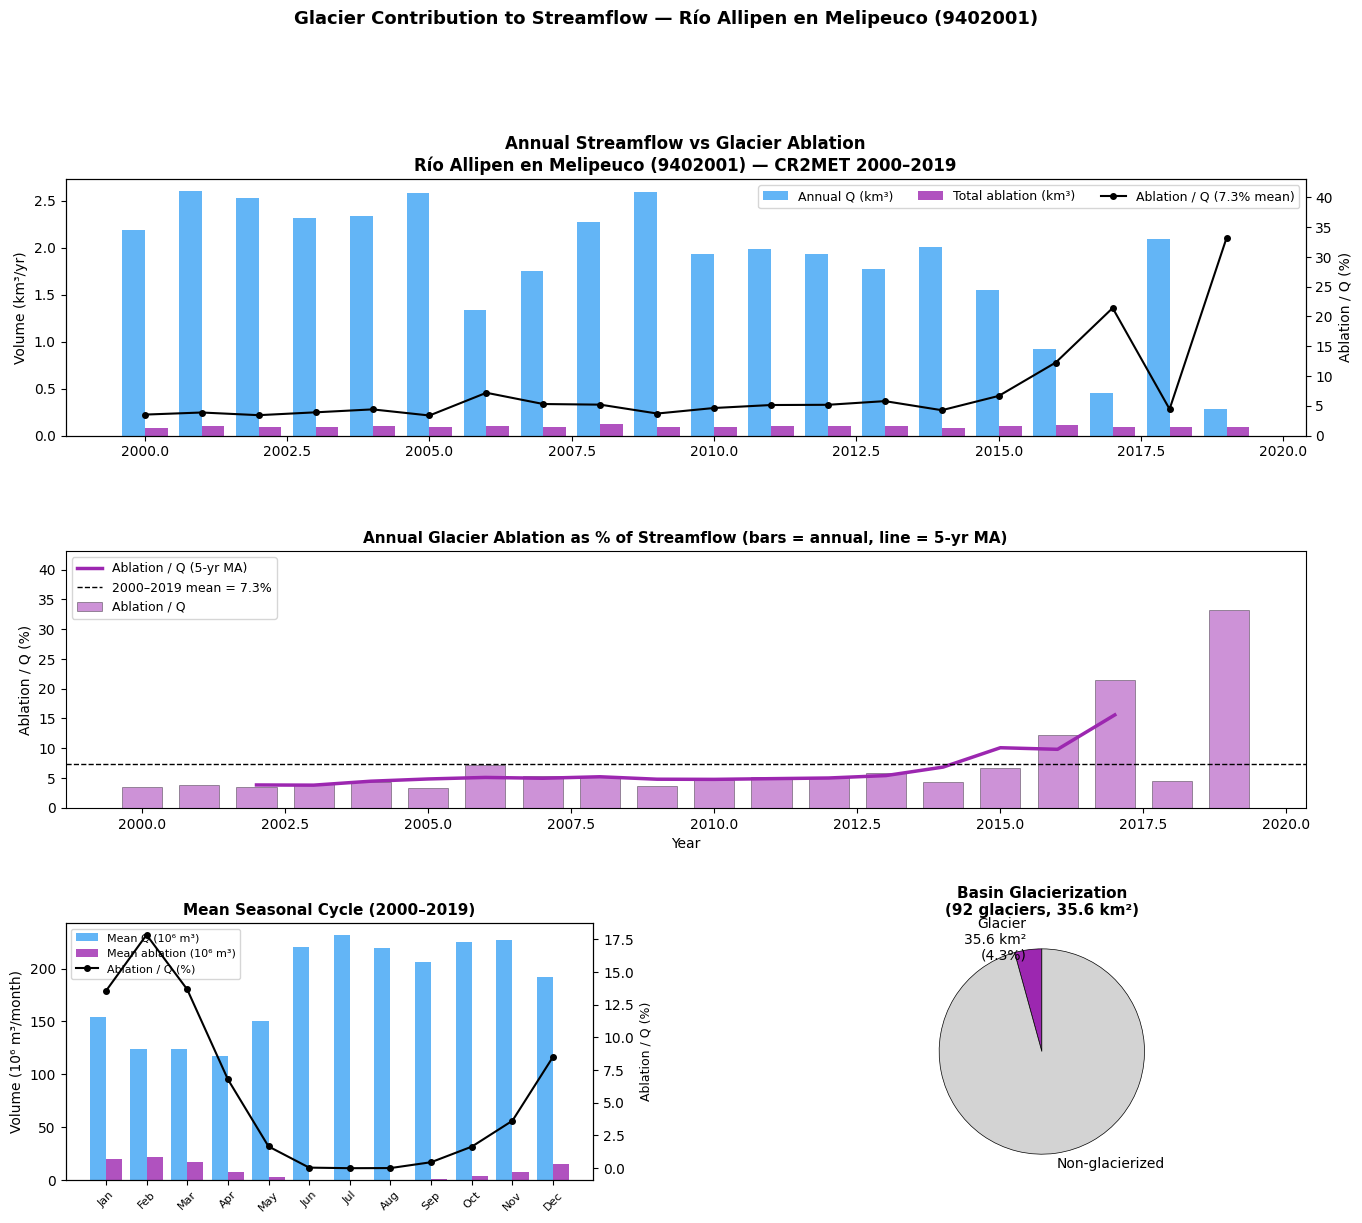

In [11]:
"""Cell 6: Plot annual + seasonal glacier contributions"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

C_Q    = '#2196F3'
C_MELT = '#9C27B0'
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Annual Q vs ablation (volumes) ───────────────────────────────
ax1  = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()

x = np.array(common_years, dtype=float)
ax1.bar(x - 0.2, q_ann   / 1e9, width=0.4, color=C_Q,    alpha=0.7, label='Annual Q (km³)')
ax1.bar(x + 0.2, gl_melt / 1e9, width=0.4, color=C_MELT, alpha=0.8, label='Total ablation (km³)')
ax1b.plot(x, frac_melt.values, '-o', color='black', markersize=4, linewidth=1.5,
          label=f'Ablation / Q ({frac_melt.mean():.1f}% mean)')

ax1.set_ylabel('Volume (km³/yr)', fontsize=10)
ax1b.set_ylabel('Ablation / Q (%)', fontsize=10)
ax1b.set_ylim(0, max(frac_melt.max() * 1.3, 10))
ax1.set_title('Annual Streamflow vs Glacier Ablation\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right', ncol=3)

# ── Panel 2: Ablation / Q fraction with 5-yr moving average ───────────────
ax2 = fig.add_subplot(gs[1, :])

ax2.bar(x, frac_melt.values, width=0.7, color=C_MELT,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Ablation / Q')

ma_melt = pd.Series(frac_melt.values, index=x).rolling(5, center=True).mean()
ax2.plot(x, ma_melt.values, '-', color=C_MELT, linewidth=2.5,
         label='Ablation / Q (5-yr MA)')
ax2.axhline(frac_melt.mean(), color='black', linestyle='--', linewidth=1,
            label=f'2000–2019 mean = {frac_melt.mean():.1f}%')

ax2.set_ylabel('Ablation / Q (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, max(frac_melt.max() * 1.3, 5))
ax2.set_title('Annual Glacier Ablation as % of Streamflow (bars = annual, line = 5-yr MA)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

# ── Panel 3: Mean seasonal cycle ──────────────────────────────────────────
ax3  = fig.add_subplot(gs[2, 0])
ax3b = ax3.twinx()
ax3.bar(np.arange(1,13) - 0.2, q_seasonal  / 1e6, width=0.4,
        color=C_Q,    alpha=0.7, label='Mean Q (10⁶ m³)')
ax3.bar(np.arange(1,13) + 0.2, gl_mon_mean / 1e6, width=0.4,
        color=C_MELT, alpha=0.8, label='Mean ablation (10⁶ m³)')
ax3b.plot(range(1,13), gl_seasonal.values, '-o',
          color='black', markersize=4, linewidth=1.5, label='Ablation / Q (%)')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(MONTH_NAMES, fontsize=8, rotation=45)
ax3.set_ylabel('Volume (10⁶ m³/month)', fontsize=10)
ax3b.set_ylabel('Ablation / Q (%)', fontsize=9)
ax3.set_title('Mean Seasonal Cycle (2000–2019)', fontsize=11, fontweight='bold')
lines3, labs3 = ax3.get_legend_handles_labels()
lines4, labs4 = ax3b.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labs3 + labs4, fontsize=8)

# ── Panel 4: Basin glacierization pie ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
glacier_pct = glacier_area / basin_area_km2 * 100
sizes  = [glacier_area, basin_area_km2 - glacier_area]
labels = [f'Glacier\n{glacier_area:.1f} km²\n({glacier_pct:.1f}%)', 'Non-glacierized']
ax4.pie(sizes, labels=labels, colors=[C_MELT, 'lightgray'],
        startangle=90, wedgeprops=dict(edgecolor='black', linewidth=0.5))
ax4.set_title(f'Basin Glacierization\n({len(rgi_ids)} glaciers, {glacier_area:.1f} km²)',
              fontsize=11, fontweight='bold')

plt.suptitle('Glacier Contribution to Streamflow — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_glacier_contribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

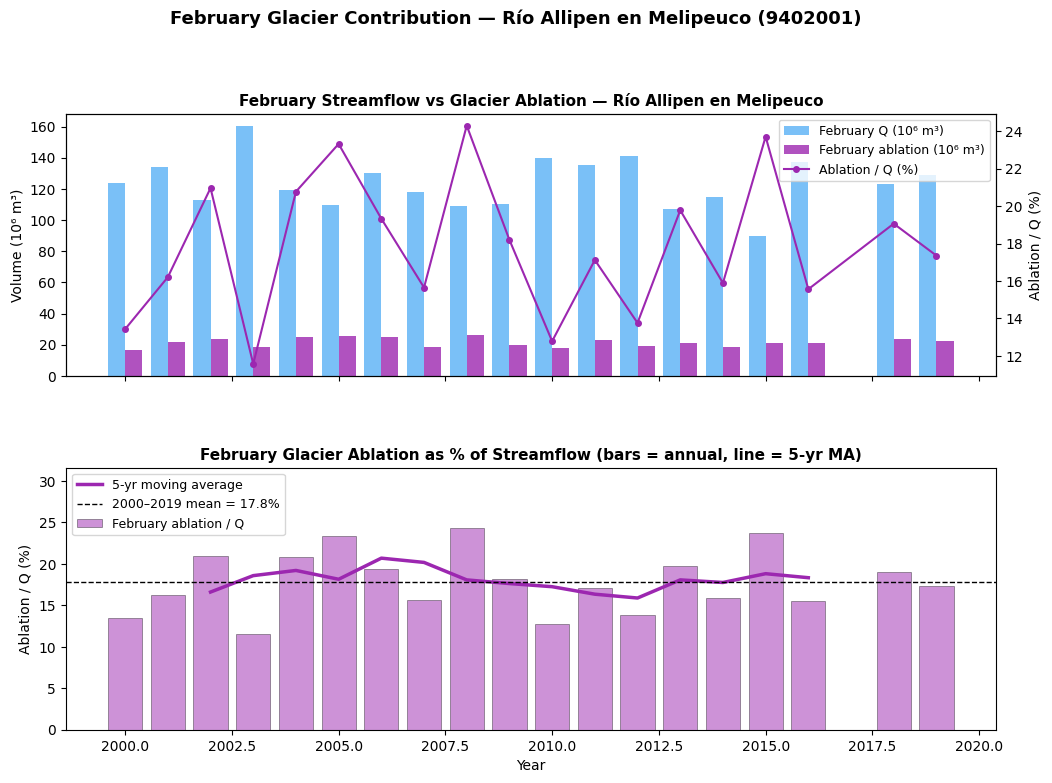


February statistics:
  Mean ablation / Q:  17.8%
  Max ablation / Q:   24.3%  (year 2008)
  Min ablation / Q:   11.6%  (year 2003)


In [8]:
"""Cell 6b: February glacier contribution timeseries (2000–2019)
   February = peak late-summer melt month in Southern Hemisphere
"""

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.35)

# Filter to February only
feb_mask  = frac_melt_mon.index.month == 2
feb_melt  = frac_melt_mon[feb_mask]
feb_q     = q_mon_c[feb_mask]
feb_gl    = gl_mon_c[feb_mask]
feb_years = feb_melt.index.year

# 5-yr moving average on February fraction
feb_ma = feb_melt.copy()
feb_ma.index = feb_years
feb_ma_roll = feb_ma.rolling(5, center=True).mean()

# ── Panel 1: February Q vs ablation (m³) ──────────────────────────────────
ax1  = axes[0]
ax1b = ax1.twinx()
ax1.bar(feb_years - 0.2, feb_q  / 1e6, width=0.4, color=C_Q,    alpha=0.6, label='February Q (10⁶ m³)')
ax1.bar(feb_years + 0.2, feb_gl / 1e6, width=0.4, color=C_MELT, alpha=0.8, label='February ablation (10⁶ m³)')
ax1b.plot(feb_years, feb_melt.values, '-o', color=C_MELT,
          markersize=4, linewidth=1.5, label='Ablation / Q (%)')
ax1.set_ylabel('Volume (10⁶ m³)', fontsize=10)
ax1b.set_ylabel('Ablation / Q (%)', fontsize=10)
ax1.set_title('February Streamflow vs Glacier Ablation — Río Allipen en Melipeuco',
              fontsize=11, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right')

# ── Panel 2: February ablation fraction + 5-yr MA ─────────────────────────
ax2 = axes[1]
ax2.bar(feb_years, feb_melt.values, color=C_MELT, alpha=0.5,
        edgecolor='black', linewidth=0.5, label='February ablation / Q')
ax2.plot(feb_years, feb_ma_roll.values, '-', color=C_MELT,
         linewidth=2.5, label='5-yr moving average')
ax2.axhline(feb_melt.mean(), color='black', linestyle='--', linewidth=1,
            label=f'2000–2019 mean = {feb_melt.mean():.1f}%')
ax2.set_ylabel('Ablation / Q (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, min(feb_melt.max() * 1.3, 100))
ax2.set_title('February Glacier Ablation as % of Streamflow (bars = annual, line = 5-yr MA)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('February Glacier Contribution — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_february_contribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f'\nFebruary statistics:')
print(f'  Mean ablation / Q:  {feb_melt.mean():.1f}%')
print(f'  Max ablation / Q:   {feb_melt.max():.1f}%  (year {feb_years[feb_melt.values.argmax()]})')
print(f'  Min ablation / Q:   {feb_melt.min():.1f}%  (year {feb_years[feb_melt.values.argmin()]})')

## now let's look seasonally: accumulation vs ablation season:

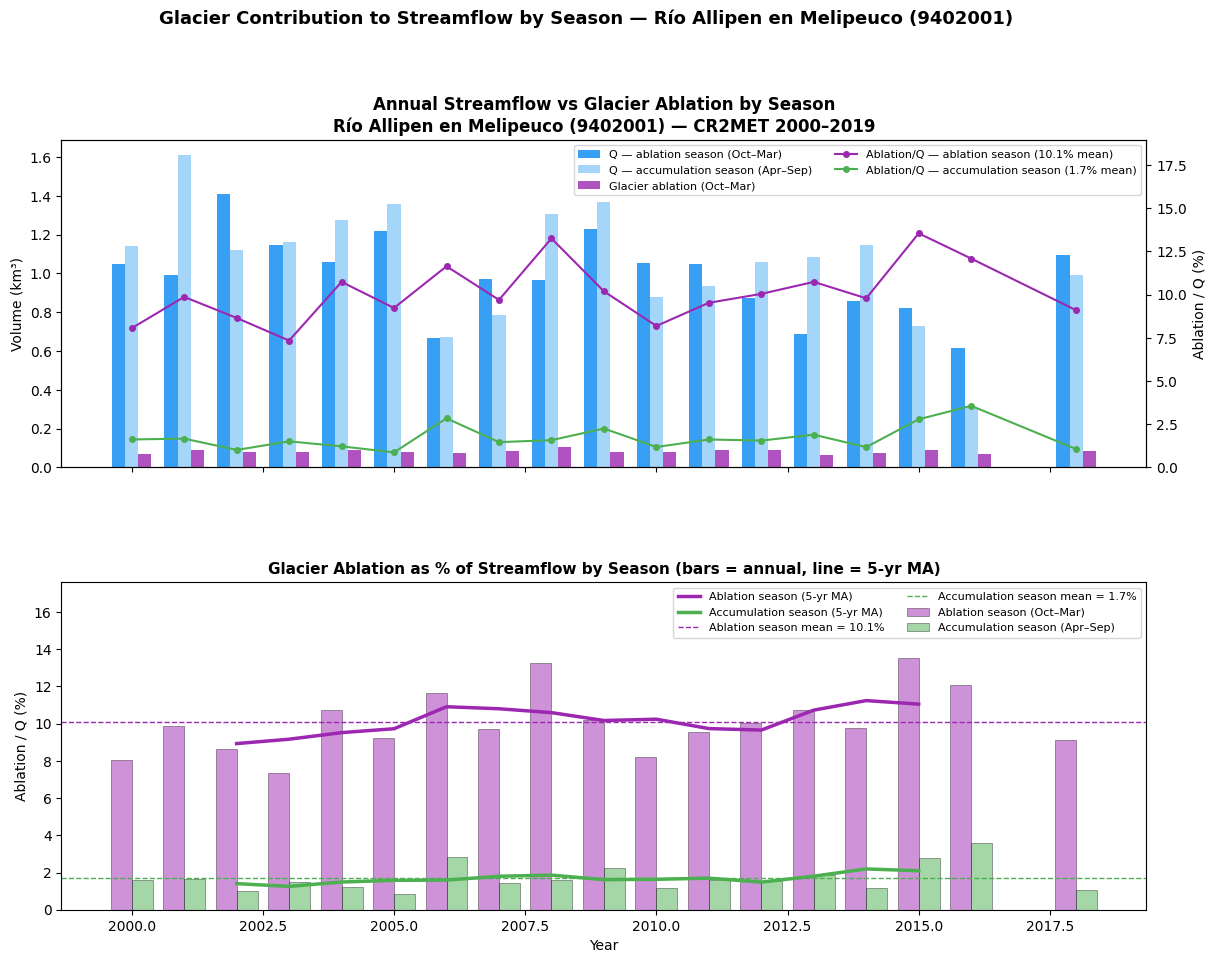

In [13]:
"""Cell 6: Plot annual glacier contributions by season"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

C_Q    = '#2196F3'
C_MELT = '#9C27B0'
C_ACC  = '#4CAF50'

# ── Seasonal split: ablation = Oct–Mar, accumulation = Apr–Sep ────────────
ablation_months     = [10, 11, 12, 1, 2, 3]
accumulation_months = [4, 5, 6, 7, 8, 9]

abl_mask = frac_melt_mon.index.month.isin(ablation_months)
acc_mask = frac_melt_mon.index.month.isin(accumulation_months)

frac_abl = frac_melt_mon[abl_mask].groupby(frac_melt_mon[abl_mask].index.year).mean()
frac_acc = frac_melt_mon[acc_mask].groupby(frac_melt_mon[acc_mask].index.year).mean()

q_abl  = q_mon_c[abl_mask].groupby(q_mon_c[abl_mask].index.year).sum()
q_acc  = q_mon_c[acc_mask].groupby(q_mon_c[acc_mask].index.year).sum()
gl_abl = gl_mon_c[abl_mask].groupby(gl_mon_c[abl_mask].index.year).sum()

common = frac_abl.index.intersection(frac_acc.index)
common = common[(common >= 2000) & (common <= 2019)]
x = np.array(common, dtype=float)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0.35)

# ── Panel 1: Q and ablation volumes by season ─────────────────────────────
ax1  = axes[0]
ax1b = ax1.twinx()

w = 0.25
ax1.bar(x - w, q_abl.loc[common]  / 1e9, width=w, color=C_Q,    alpha=0.9,
        label='Q — ablation season (Oct–Mar)')
ax1.bar(x,     q_acc.loc[common]  / 1e9, width=w, color=C_Q,    alpha=0.4,
        label='Q — accumulation season (Apr–Sep)')
ax1.bar(x + w, gl_abl.loc[common] / 1e9, width=w, color=C_MELT, alpha=0.8,
        label='Glacier ablation (Oct–Mar)')

ax1b.plot(x, frac_abl.loc[common].values, '-o', color=C_MELT,
          markersize=4, linewidth=1.5,
          label=f'Ablation/Q — ablation season ({frac_abl.loc[common].mean():.1f}% mean)')
ax1b.plot(x, frac_acc.loc[common].values, '-o', color=C_ACC,
          markersize=4, linewidth=1.5,
          label=f'Ablation/Q — accumulation season ({frac_acc.loc[common].mean():.1f}% mean)')

ax1.set_ylabel('Volume (km³)', fontsize=10)
ax1b.set_ylabel('Ablation / Q (%)', fontsize=10)
ax1b.set_ylim(0, max(frac_abl.loc[common].max() * 1.4, 10))
ax1.set_title('Annual Streamflow vs Glacier Ablation by Season\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right', ncol=2)

# ── Panel 2: Ablation/Q fraction by season with 5-yr MA ───────────────────
ax2 = axes[1]

ax2.bar(x - 0.2, frac_abl.loc[common].values, width=0.4, color=C_MELT,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Ablation season (Oct–Mar)')
ax2.bar(x + 0.2, frac_acc.loc[common].values, width=0.4, color=C_ACC,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Accumulation season (Apr–Sep)')

ma_abl = pd.Series(frac_abl.loc[common].values, index=x).rolling(5, center=True).mean()
ma_acc = pd.Series(frac_acc.loc[common].values, index=x).rolling(5, center=True).mean()
ax2.plot(x, ma_abl.values, '-', color=C_MELT, linewidth=2.5, label='Ablation season (5-yr MA)')
ax2.plot(x, ma_acc.values, '-', color=C_ACC,  linewidth=2.5, label='Accumulation season (5-yr MA)')

ax2.axhline(frac_abl.loc[common].mean(), color=C_MELT, linestyle='--', linewidth=1,
            label=f'Ablation season mean = {frac_abl.loc[common].mean():.1f}%')
ax2.axhline(frac_acc.loc[common].mean(), color=C_ACC,  linestyle='--', linewidth=1,
            label=f'Accumulation season mean = {frac_acc.loc[common].mean():.1f}%')

ax2.set_ylabel('Ablation / Q (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, max(frac_abl.loc[common].max() * 1.3, 5))
ax2.set_title('Glacier Ablation as % of Streamflow by Season (bars = annual, line = 5-yr MA)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, ncol=2)

plt.suptitle('Glacier Contribution to Streamflow by Season — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_glacier_contribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

## by season

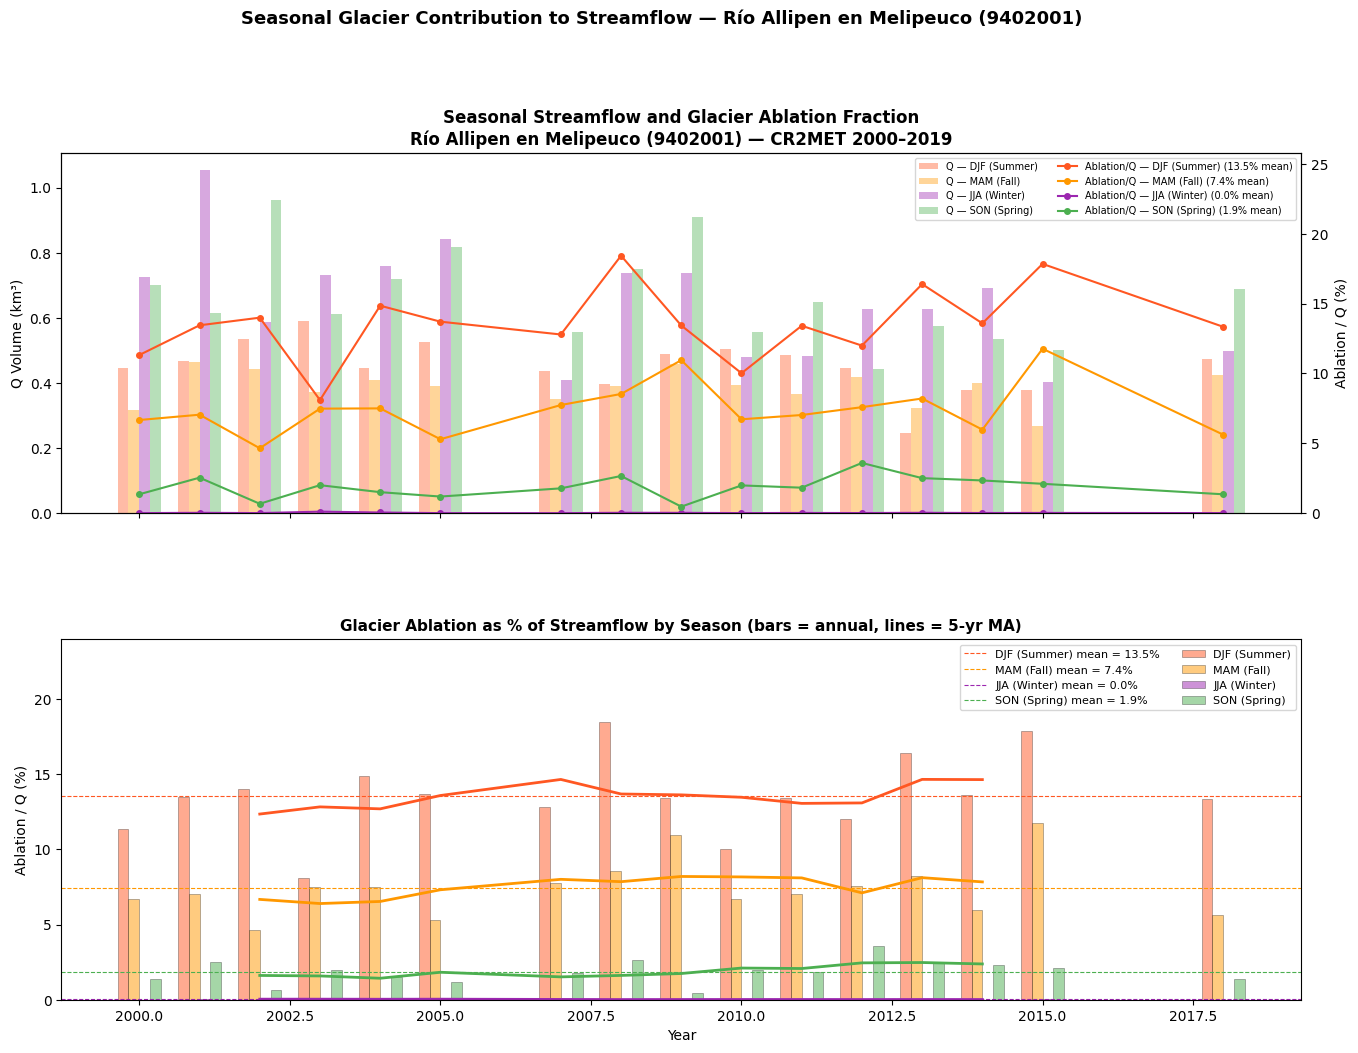

In [14]:
"""Cell 6: Plot annual glacier contributions by meteorological season (SH)"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

C_Q      = '#2196F3'
C_DJF    = '#FF5722'   # summer
C_MAM    = '#FF9800'   # fall
C_JJA    = '#9C27B0'   # winter
C_SON    = '#4CAF50'   # spring

seasons = {
    'DJF (Summer)': {'months': [12, 1, 2],  'color': C_DJF},
    'MAM (Fall)':   {'months': [3, 4, 5],   'color': C_MAM},
    'JJA (Winter)': {'months': [6, 7, 8],   'color': C_JJA},
    'SON (Spring)': {'months': [9, 10, 11], 'color': C_SON},
}

# ── Compute seasonal fractions and volumes ────────────────────────────────
seasonal_data = {}
for name, info in seasons.items():
    mask      = frac_melt_mon.index.month.isin(info['months'])
    frac_s    = frac_melt_mon[mask].groupby(frac_melt_mon[mask].index.year).mean()
    q_s       = q_mon_c[mask].groupby(q_mon_c[mask].index.year).sum()
    gl_s      = gl_mon_c[mask].groupby(gl_mon_c[mask].index.year).sum()
    seasonal_data[name] = {'frac': frac_s, 'q': q_s, 'gl': gl_s, 'color': info['color']}

# Common years
all_idx = [v['frac'].index for v in seasonal_data.values()]
common  = all_idx[0]
for idx in all_idx[1:]:
    common = common.intersection(idx)
common = common[(common >= 2000) & (common <= 2019)]
x = np.array(common, dtype=float)

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
fig.subplots_adjust(hspace=0.35)

# ── Panel 1: Q and ablation volumes by season ─────────────────────────────
ax1  = axes[0]
ax1b = ax1.twinx()

n  = len(seasons)
w  = 0.18
offsets = np.linspace(-(n-1)/2 * w, (n-1)/2 * w, n)

for (name, data), offset in zip(seasonal_data.items(), offsets):
    ax1.bar(x + offset, data['q'].loc[common] / 1e9, width=w,
            color=data['color'], alpha=0.4, label=f'Q — {name}')

# Ablation bars — only plot summer (DJF) since melt is negligible other seasons
# but show all four fraction lines
for (name, data), offset in zip(seasonal_data.items(), offsets):
    ax1b.plot(x, data['frac'].loc[common].values, '-o',
              color=data['color'], markersize=4, linewidth=1.5,
              label=f'Ablation/Q — {name} ({data["frac"].loc[common].mean():.1f}% mean)')

ax1.set_ylabel('Q Volume (km³)', fontsize=10)
ax1b.set_ylabel('Ablation / Q (%)', fontsize=10)
ax1b.set_ylim(0, max(max(d['frac'].loc[common].max() for d in seasonal_data.values()) * 1.4, 10))
ax1.set_title('Seasonal Streamflow and Glacier Ablation Fraction\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=7, loc='upper right', ncol=2)

# ── Panel 2: Ablation/Q fraction by season with 5-yr MA ───────────────────
ax2 = axes[1]

for (name, data), offset in zip(seasonal_data.items(), offsets):
    ax2.bar(x + offset, data['frac'].loc[common].values, width=w,
            color=data['color'], alpha=0.5, edgecolor='black', linewidth=0.4,
            label=name)
    ma = pd.Series(data['frac'].loc[common].values, index=x).rolling(5, center=True).mean()
    ax2.plot(x, ma.values, '-', color=data['color'], linewidth=2.0)
    ax2.axhline(data['frac'].loc[common].mean(), color=data['color'],
                linestyle='--', linewidth=0.8,
                label=f'{name} mean = {data["frac"].loc[common].mean():.1f}%')

ax2.set_ylabel('Ablation / Q (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, max(max(d['frac'].loc[common].max() for d in seasonal_data.values()) * 1.3, 5))
ax2.set_title('Glacier Ablation as % of Streamflow by Season (bars = annual, lines = 5-yr MA)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, ncol=2)

plt.suptitle('Seasonal Glacier Contribution to Streamflow — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_glacier_contribution_seasons.png',
            dpi=300, bbox_inches='tight')
plt.show()

## by month: 

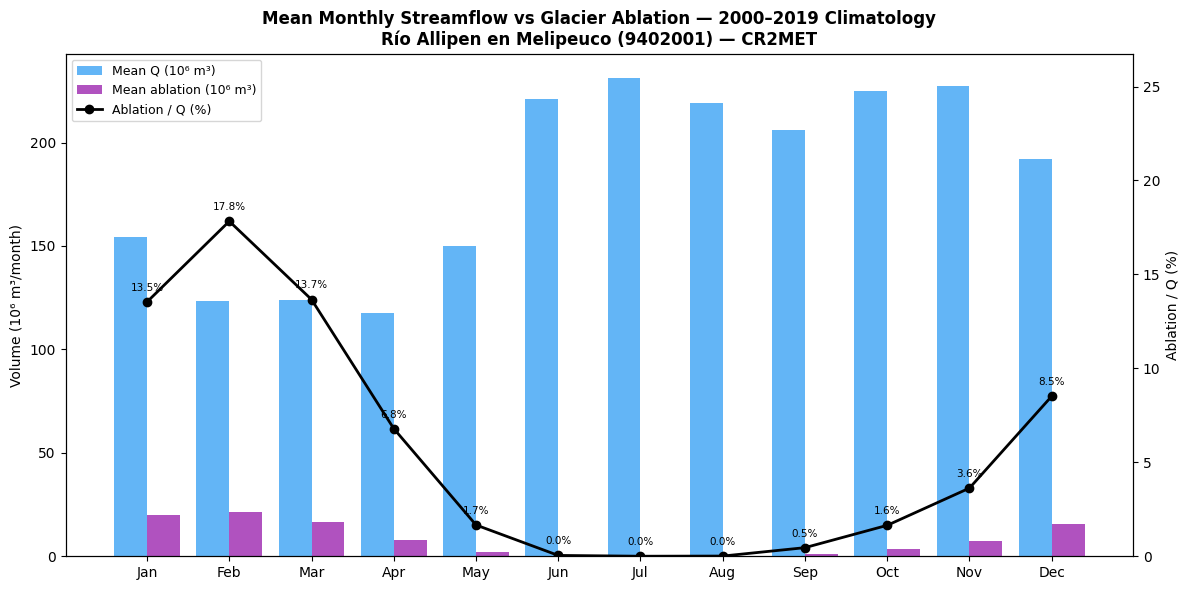

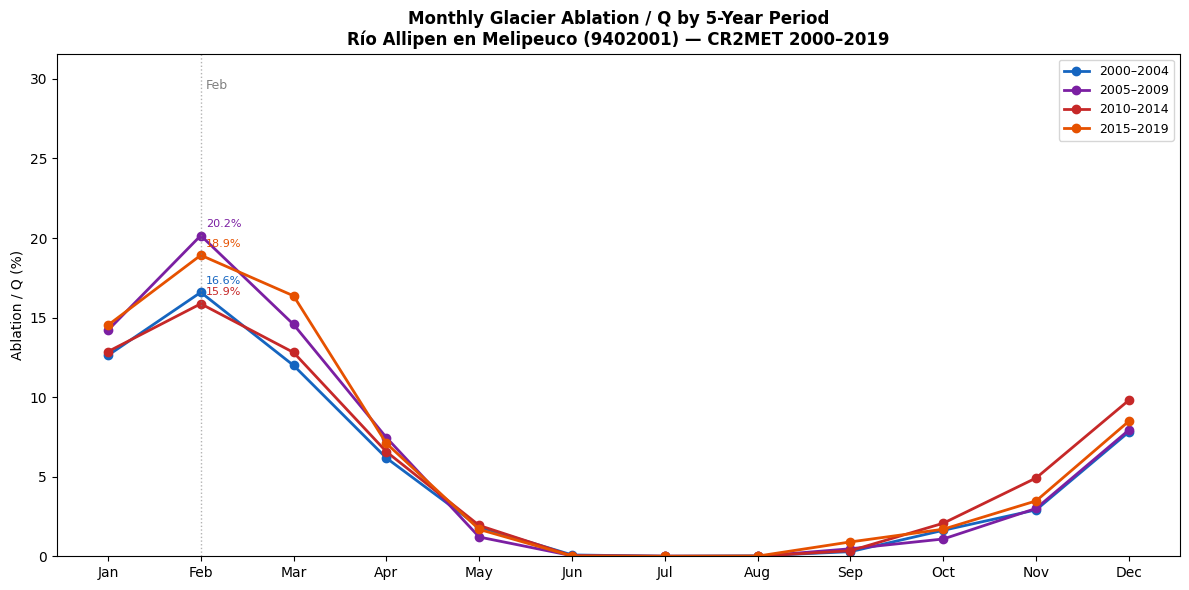

Monthly ablation/Q by 5-year period (%):
Month    2000–2004   2005–2009   2010–2014   2015–2019   2000-2019
------------------------------------------------------
Jan           12.6        14.2        12.9        14.5        13.5
Feb           16.6        20.2        15.9        18.9        17.8
Mar           12.0        14.6        12.8        16.4        13.7
Apr            6.2         7.5         6.6         7.1         6.8
May            1.8         1.2         1.9         1.7         1.7
Jun            0.1         0.0         0.0         0.0         0.0
Jul            0.0         0.0         0.0         0.0         0.0
Aug            0.0         0.0         0.0         0.0         0.0
Sep            0.3         0.5         0.3         0.9         0.5
Oct            1.6         1.1         2.1         1.7         1.6
Nov            2.9         3.0         4.9         3.5         3.6
Dec            7.8         7.9         9.8         8.5         8.5


In [15]:
"""Cell 6: Monthly glacier contribution — climatology and 5-yr evolution"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

C_Q    = '#2196F3'
C_MELT = '#9C27B0'
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Filter to 2000–2019 ───────────────────────────────────────────────────
mask_period = (q_mon_c.index.year >= 2000) & (q_mon_c.index.year <= 2019)
q_p    = q_mon_c[mask_period]
gl_p   = gl_mon_c[mask_period]
frac_p = frac_melt_mon[mask_period]

# ── Plot 1: Monthly climatology (mean over 2000–2019) ─────────────────────
q_clim    = q_p.groupby(q_p.index.month).mean()
gl_clim   = gl_p.groupby(gl_p.index.month).mean()
frac_clim = frac_p.groupby(frac_p.index.month).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1b = ax1.twinx()

months = np.arange(1, 13)
ax1.bar(months - 0.2, q_clim.values  / 1e6, width=0.4, color=C_Q,
        alpha=0.7, label='Mean Q (10⁶ m³)')
ax1.bar(months + 0.2, gl_clim.values / 1e6, width=0.4, color=C_MELT,
        alpha=0.8, label='Mean ablation (10⁶ m³)')
ax1b.plot(months, frac_clim.values, '-o', color='black',
          markersize=6, linewidth=2, label='Ablation / Q (%)')

# Annotate fraction values
for m, f in zip(months, frac_clim.values):
    ax1b.annotate(f'{f:.1f}%', xy=(m, f), xytext=(0, 8),
                  textcoords='offset points', ha='center', fontsize=7.5,
                  color='black')

ax1.set_xticks(months)
ax1.set_xticklabels(MONTH_NAMES, fontsize=10)
ax1.set_ylabel('Volume (10⁶ m³/month)', fontsize=10)
ax1b.set_ylabel('Ablation / Q (%)', fontsize=10)
ax1b.set_ylim(0, frac_clim.max() * 1.5)
ax1.set_title('Mean Monthly Streamflow vs Glacier Ablation — 2000–2019 Climatology\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_monthly_climatology.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 2: 5-yr average ablation/Q fraction by month ─────────────────────
# Periods: 2000–2004, 2005–2009, 2010–2014, 2015–2019
periods = {
    '2000–2004': (2000, 2004),
    '2005–2009': (2005, 2009),
    '2010–2014': (2010, 2014),
    '2015–2019': (2015, 2019),
}
period_colors = ['#1565C0', '#7B1FA2', '#C62828', '#E65100']

fig, ax = plt.subplots(figsize=(12, 6))

for (label, (y0, y1)), color in zip(periods.items(), period_colors):
    mask = (frac_p.index.year >= y0) & (frac_p.index.year <= y1)
    frac_period = frac_p[mask].groupby(frac_p[mask].index.month).mean()
    ax.plot(months, frac_period.reindex(months).values, '-o',
            color=color, linewidth=2, markersize=6, label=label)
    # Annotate Feb value
    feb_val = frac_period.get(2, np.nan)
    if not np.isnan(feb_val):
        ax.annotate(f'{feb_val:.1f}%', xy=(2, feb_val),
                    xytext=(4, 6), textcoords='offset points',
                    fontsize=8, color=color)

ax.set_xticks(months)
ax.set_xticklabels(MONTH_NAMES, fontsize=10)
ax.set_ylabel('Ablation / Q (%)', fontsize=10)
ax.set_ylim(0, frac_p.groupby(frac_p.index.month).max().max() * 1.3)
ax.set_title('Monthly Glacier Ablation / Q by 5-Year Period\n'
             'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(2, color='gray', linestyle=':', linewidth=1, alpha=0.6)  # highlight Feb
ax.text(2.05, ax.get_ylim()[1] * 0.95, 'Feb', fontsize=9,
        color='gray', va='top')

plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_monthly_5yr_periods.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ── Print summary table ───────────────────────────────────────────────────
print('Monthly ablation/Q by 5-year period (%):')
print(f'{"Month":<6}', end='')
for label in periods:
    print(f'{label:>12}', end='')
print(f'{"2000-2019":>12}')
print('-' * 54)
for m, name in zip(months, MONTH_NAMES):
    print(f'{name:<6}', end='')
    for y0, y1 in periods.values():
        mask = (frac_p.index.year >= y0) & (frac_p.index.year <= y1)
        val  = frac_p[mask & (frac_p.index.month == m)].mean()
        print(f'{val:>12.1f}', end='')
    print(f'{frac_clim[m]:>12.1f}')

## hmm, looks like glacier melt contributions to streamflow peaked in 2015-2019 during the mega drought 

## summary tables

In [9]:
"""Cell 7: Summary tables — annual and seasonal glacier contribution"""

# ── Annual summary ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Q_km3':                    (q_ann    / 1e9).round(4),
    'Ablation_km3':             (gl_melt  / 1e9).round(4),
    'Net_vol_change_km3':       (gl_imbal / 1e9).round(4),
    'Ablation_pct':             frac_melt.round(2),
    'Net_vol_change_pct':       frac_imbal.round(2),
}, index=common_years)

print('── Annual Summary ───────────────────────────────────────────────')
print(summary.to_string())

# ── Seasonal summary ──────────────────────────────────────────────────────
seasonal_summary = pd.DataFrame({
    'Mean_Q_m3':        q_seasonal.round(0),
    'Mean_ablation_m3': gl_mon_mean.round(0),
    'Ablation_pct':     gl_seasonal.round(2),
}, index=MONTH_NAMES)

print('\n── Seasonal Summary (mean across 2000–2019) ─────────────────────')
print(seasonal_summary.to_string())

print(f'\n── Key Statistics ───────────────────────────────────────────────')
print(f'Basin area:                        {basin_area_km2:.1f} km²')
print(f'Glacier area:                      {glacier_area:.1f} km²  ({glacier_pct:.1f}% of basin)')
print(f'N glaciers:                        {len(rgi_ids)}')
print(f'Ablation / Q:                      {frac_melt.mean():.1f}%  '
      f'(total annual ablation flux)')
print(f'Annual net vol change / Q:         {frac_imbal.mean():.1f}%  '
      f'(annual accumulation - ablation)')
print(f'Ablation offset by accumulation:   {(frac_melt.mean() - frac_imbal.mean()):.1f}%')
print(f'Peak ablation month:               {MONTH_NAMES[gl_seasonal.idxmax()-1]} '
      f'({gl_seasonal.max():.1f}%)')
print(f'Ablation / net vol change ratio:   {gl_melt.mean() / gl_imbal.mean():.1f}x')

── Annual Summary ───────────────────────────────────────────────
       Q_km3  Ablation_km3  Net_vol_change_km3  Ablation_pct  Net_vol_change_pct
2000  2.1892        0.0770              0.0000          3.52                0.00
2001  2.6006        0.1005              0.0164          3.87                0.63
2002  2.5264        0.0864              0.0069          3.42                0.27
2003  2.3093        0.0900              0.0211          3.90                0.91
2004  2.3317        0.1024              0.0336          4.39                1.44
2005  2.5768        0.0867              0.0000          3.36                0.00
2006  1.3392        0.0962              0.0032          7.18                0.24
2007  1.7555        0.0929              0.0336          5.29                1.92
2008  2.2744        0.1180              0.0422          5.19                1.86
2009  2.5941        0.0958              0.0154          3.69                0.59
2010  1.9327        0.0894              0.0

## Results: WOW. In 2019, glacier melt represents 33% of streamflow (calculated as ablation/Q) for the Allipen. 

* The 3.5x ratio means accumulation offsets about 68% of what melts each year
* 7.3% of total annual streamflow comes from glaciers (avg across study period). 2.3% of this isn't replenished by accumulation. Think of this as irreperable loss. 
* The early years (2000–2005) show ablation/Q around 3–4% and net vol change near 0–1%. By 2016–2019 those jump to 12–33% and 7–11% respectively. TLDR: Glacier melt contribution to streamflow increases in drought years, driven by declining precipitation rather than accelerating melt — glaciers act as a buffer maintaining stable water supply when rain/snowmelt-fed runoff collapses.
* mean Feb glacier melt contribution to streamflow is 17.8%. 2008 was highest year of glacier importance (24.3% of feb streamflow) while min ws 11.6% in 2003. WAY higher than I expected. 

Total glaciers in RGI: 13246

Loading cluster NetCDFs...
  ✓ OT3: 34 glaciers
  ✓ DA1: 422 glaciers
  ✓ DA2: 200 glaciers
  ✓ DA3: 410 glaciers
  ✓ WA1: 678 glaciers
  ✓ WA2: 2924 glaciers
  ✓ WA3: 447 glaciers
  ✓ WA4: 4749 glaciers
  ✓ WA5: 711 glaciers
  ✓ WA6: 2671 glaciers
✓ extract_basin_outputs() defined

Basin 91: 77 glaciers across clusters ['WA1']
  WA1: matched 77 glaciers

Basin 94: 189 glaciers across clusters ['WA1']
  WA1: matched 189 glaciers

Year  Melt (m³)    Area (km²)   MB (m w.e.)
--------------------------------------------------
2000  1.99e+08   97.58      0.616
2001  2.71e+08   104.64      -0.060
2002  2.34e+08   102.12      0.315
2003  2.36e+08   101.96      -0.139
2004  2.76e+08   100.36      -0.535
2005  2.36e+08   98.94      0.686
2006  2.58e+08   107.60      0.319
2007  2.50e+08   104.52      -0.576
2008  3.30e+08   103.71      -0.824
2009  2.67e+08   100.07      0.014
2010  2.38e+08   100.10      -0.446
2011  2.79e+08   99.24      -0.785
2012  2.74e+08   

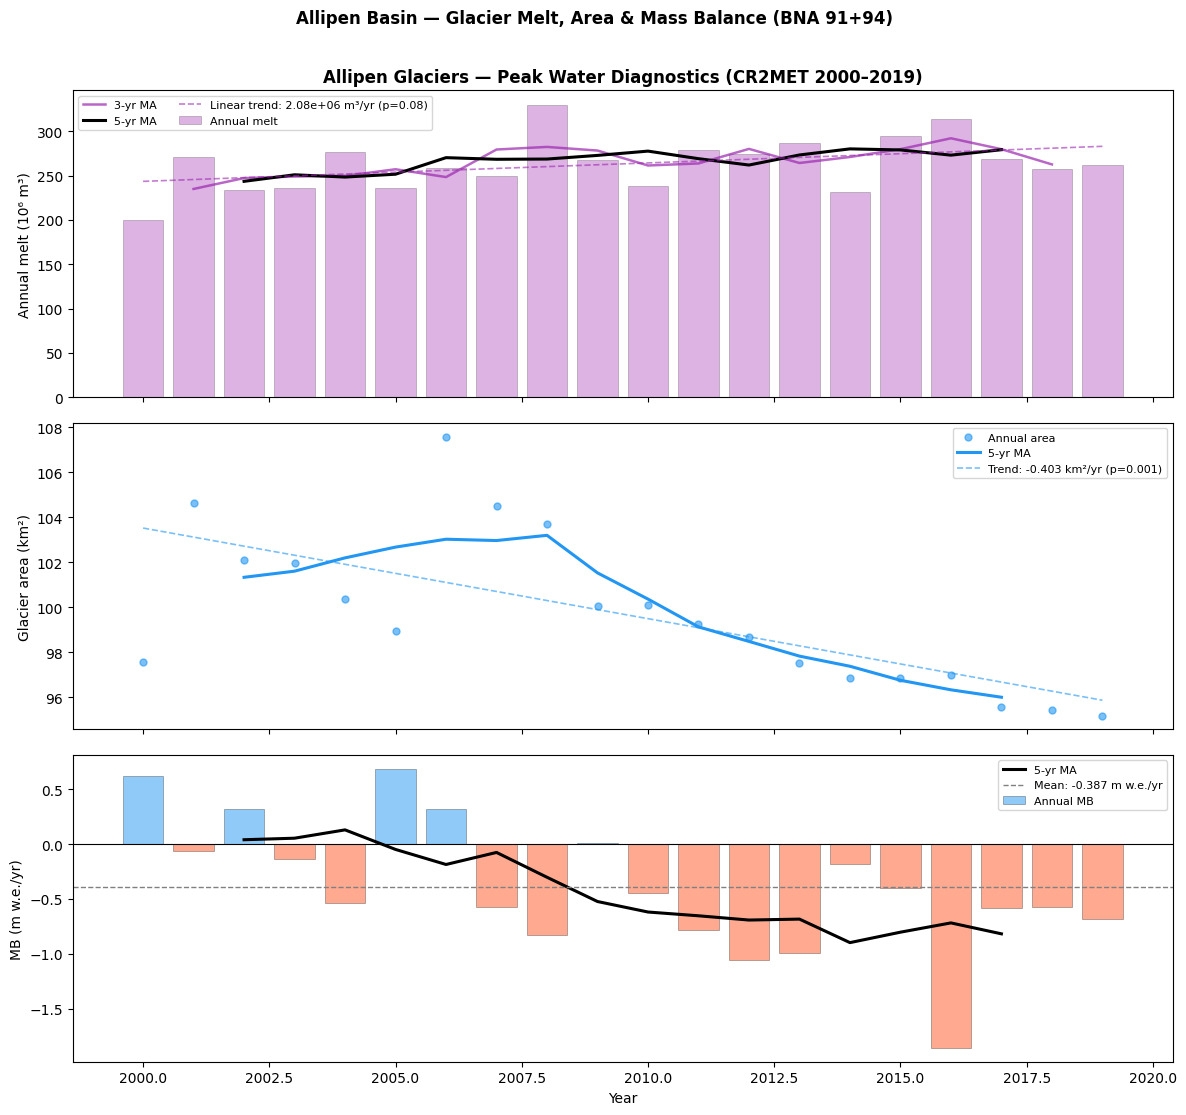

In [1]:
"""
Cell A+B+C: Load data, define extract_basin_outputs(), run Allipen analysis,
            and plot peak water diagnostics
"""

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

# ── Constants & paths ─────────────────────────────────────────────────────
ICE_DENSITY   = 900
WATER_DENSITY = 1000

BASE_PATH  = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET'
RGI_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

C_Q     = '#2196F3'
C_IMBAL = '#FF5722'
C_MELT  = '#9C27B0'

NC_SUFFIX = {
    'OT3': 'run_output_2000_2019_hydro_TC_OT3.nc',
    'DA1': 'run_output_2000_2019_hydro_TC_DA1.nc',
    'DA2': 'run_output_2000_2019_hydro_TC_DA2.nc',
    'DA3': 'run_output_2000_2019_hydro_TC_DA3.nc',
    'WA1': 'run_output_2000_2019_hydro_TC_WA1.nc',
    'WA2': 'run_output_2000_2019_hydro_TC_WA2.nc',
    'WA3': 'run_output_2000_2019_hydro_TC_WA3.nc',
    'WA4': 'run_output_2000_2019_hydro_TC_WA4.nc',
    'WA5': 'run_output_2000_2019_hydro_TC_WA5.nc',
    'WA6': 'run_output_2000_2019_hydro_TC_WA6.nc',
}

# ── Load RGI mapping ───────────────────────────────────────────────────────
rgi = pd.read_csv(RGI_PATH)
rgi['COD_CUEN'] = rgi['COD_CUEN'].astype(str).str.lstrip('0')
rgi['COD_CUEN'] = pd.to_numeric(rgi['COD_CUEN'], errors='coerce').astype('Int64')
print(f'Total glaciers in RGI: {len(rgi)}')

# ── Load all cluster NetCDFs ───────────────────────────────────────────────
print('\nLoading cluster NetCDFs...')
nc_datasets = {}
for cluster, fname in NC_SUFFIX.items():
    nc_path = os.path.join(BASE_PATH, cluster, fname)
    if os.path.exists(nc_path):
        nc_datasets[cluster] = xr.open_dataset(nc_path)
        print(f'  ✓ {cluster}: {len(nc_datasets[cluster].rgi_id)} glaciers')
    else:
        print(f'  ✗ {cluster}: file not found — {nc_path}')

# ── Define extract_basin_outputs() ────────────────────────────────────────
def extract_basin_outputs(basin_code, rgi_df, nc_datasets):
    basin_rgi = rgi_df[rgi_df['COD_CUEN'] == basin_code]
    if len(basin_rgi) == 0:
        print(f'  Basin {basin_code}: no glaciers found')
        return None

    rgi_ids    = basin_rgi['RGIId'].values
    clusters   = basin_rgi['Cluster'].unique()
    n_glaciers = len(rgi_ids)
    print(f'\nBasin {basin_code}: {n_glaciers} glaciers across clusters {clusters.tolist()}')

    vol_all = []; area_all = []; melt_all = []; years_ref = None

    for cluster in clusters:
        if cluster not in nc_datasets:
            print(f'  WARNING: {cluster} not loaded — skipping')
            continue
        ds        = nc_datasets[cluster]
        nc_ids    = ds['rgi_id'].values
        mask      = np.isin(nc_ids, rgi_ids)
        n_matched = mask.sum()
        if n_matched == 0:
            print(f'  WARNING: no glaciers matched in {cluster}')
            continue
        print(f'  {cluster}: matched {n_matched} glaciers')
        years = ds['time'].values.astype(int)
        if years_ref is None:
            years_ref = years
        vol_all.append(ds['volume'].sel(rgi_id=nc_ids[mask]).sum(dim='rgi_id').values)
        area_all.append(ds['area'].sel(rgi_id=nc_ids[mask]).sum(dim='rgi_id').values)
        melt_all.append(ds['melt_on_glacier_monthly'].sel(
            rgi_id=nc_ids[mask]).sum(dim='rgi_id').values)

    if not vol_all:
        print(f'  Basin {basin_code}: no data extracted')
        return None

    vol_total  = np.sum(vol_all,  axis=0)
    area_total = np.sum(area_all, axis=0)
    melt_total = np.sum(melt_all, axis=0)

    vol_series  = pd.Series(vol_total,  index=years_ref, name='volume_m3')
    area_series = pd.Series(area_total, index=years_ref, name='area_m2')

    dvol_annual = vol_series.diff().shift(-1)
    dwater_ann  = (-dvol_annual * (ICE_DENSITY / WATER_DENSITY)).clip(lower=0)
    dwater_ann.name = 'net_ice_loss_water_m3'

    area_mean  = (area_series + area_series.shift(1)) / 2
    mb_mwe_ann = dvol_annual * ICE_DENSITY / area_mean / WATER_DENSITY
    mb_mwe_ann.name = 'mb_m_we'

    melt_df = pd.DataFrame(melt_total, index=years_ref, columns=range(1, 13))
    melt_monthly = melt_df.stack()
    melt_monthly.index = pd.to_datetime(
        [f'{y}-{m:02d}-01' for y, m in melt_monthly.index])
    melt_monthly = melt_monthly.sort_index() / WATER_DENSITY
    melt_monthly.name = 'melt_on_glacier_m3'

    melt_annual = melt_monthly.resample('YE').sum()
    melt_annual.index = melt_annual.index.year

    return {
        'rgi_ids': rgi_ids, 'clusters': clusters.tolist(), 'years': years_ref,
        'vol_series': vol_series, 'dwater_ann': dwater_ann,
        'mb_mwe_ann': mb_mwe_ann, 'melt_monthly': melt_monthly,
        'melt_annual': melt_annual, 'area_series': area_series,
        'glacier_area_km2': area_series.mean() / 1e6, 'n_glaciers': n_glaciers,
    }

print('✓ extract_basin_outputs() defined')

# ── Extract Allipen basin outputs ─────────────────────────────────────────
out_91 = extract_basin_outputs(91, rgi, nc_datasets)
out_94 = extract_basin_outputs(94, rgi, nc_datasets)

# ── Compute combined Allipen MB ───────────────────────────────────────────
def basin_mb(out):
    dvol      = out['vol_series'].diff()
    area_mean = (out['area_series'] + out['area_series'].shift(1)) / 2
    mb        = dvol * ICE_DENSITY / area_mean / WATER_DENSITY
    mb        = mb.shift(-1)
    return mb[(mb.index >= 2000) & (mb.index <= 2019)].dropna()

vol_allipen   = out_91['vol_series']  + out_94['vol_series']
area_allipen  = out_91['area_series'] + out_94['area_series']
dvol_allipen  = vol_allipen.diff().shift(-1)
area_mean_all = (area_allipen + area_allipen.shift(1)) / 2
mb_allipen    = dvol_allipen * ICE_DENSITY / area_mean_all / WATER_DENSITY

# ── Peak water diagnostics ────────────────────────────────────────────────
melt_allipen = out_91['melt_monthly'] + out_94['melt_monthly']
melt_ann     = melt_allipen.resample('YE').sum()
melt_ann.index = melt_ann.index.year
melt_ann     = melt_ann.loc[2000:2019]

area_ann = ((out_91['area_series'] + out_94['area_series']) / 1e6).loc[2000:2019]
mb_ann   = mb_allipen.loc[2000:2019]

slope,   intercept, _, p,   _ = linregress(melt_ann.index, melt_ann.values)
slope_a, _,         _, p_a, _ = linregress(area_ann.index, area_ann.values)

# Moving averages
melt_ma3 = pd.Series(melt_ann.values, index=melt_ann.index).rolling(3, center=True).mean()
melt_ma5 = pd.Series(melt_ann.values, index=melt_ann.index).rolling(5, center=True).mean()
area_ma5 = pd.Series(area_ann.values, index=area_ann.index).rolling(5, center=True).mean()
mb_ma5   = pd.Series(mb_ann.values,   index=mb_ann.index  ).rolling(5, center=True).mean()

# Print summary table
print('\nYear  Melt (m³)    Area (km²)   MB (m w.e.)')
print('-' * 50)
for yr in range(2000, 2020):
    if yr in melt_ann.index and yr in area_ann.index:
        mb_val = mb_ann[yr] if yr in mb_ann.index else float('nan')
        print(f'{yr}  {melt_ann[yr]:.2e}   {area_ann[yr]:.2f}      {mb_val:.3f}')

print(f'\nMelt volume trend: {slope:.2e} m³/yr  (p={p:.3f})')
print(f'  → {"INCREASING" if slope > 0 else "DECREASING"} {"(significant)" if p < 0.05 else "(not significant)"}')
print(f'Area trend:        {slope_a:.3f} km²/yr  (p={p_a:.3f})')
print(f'  → {"INCREASING" if slope_a > 0 else "DECREASING"} {"(significant)" if p_a < 0.05 else "(not significant)"}')
print(f'\nMean MB   2000–2009: {mb_ann.loc[2000:2009].mean():.3f} m w.e./yr')
print(f'Mean MB   2010–2019: {mb_ann.loc[2010:2019].mean():.3f} m w.e./yr')
print(f'Mean melt 2000–2009: {melt_ann.loc[2000:2009].mean():.2e} m³/yr')
print(f'Mean melt 2010–2019: {melt_ann.loc[2010:2019].mean():.2e} m³/yr')

# ── Plot: Peak water diagnostics ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.subplots_adjust(hspace=0.35)

# Panel 1: Melt + moving averages
axes[0].bar(melt_ann.index, melt_ann.values / 1e6,
            color=C_MELT, alpha=0.35, edgecolor='black', linewidth=0.4,
            label='Annual melt')
axes[0].plot(melt_ann.index, melt_ma3.values / 1e6, '-',
             color=C_MELT, linewidth=1.8, alpha=0.7, label='3-yr MA')
axes[0].plot(melt_ann.index, melt_ma5.values / 1e6, '-',
             color='black', linewidth=2.2, label='5-yr MA')
axes[0].plot(melt_ann.index, (slope * melt_ann.index + intercept) / 1e6, '--',
             color=C_MELT, linewidth=1.2, alpha=0.6,
             label=f'Linear trend: {slope:.2e} m³/yr (p={p:.2f})')
axes[0].set_ylabel('Annual melt (10⁶ m³)', fontsize=10)
axes[0].set_title('Allipen Glaciers — Peak Water Diagnostics (CR2MET 2000–2019)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)

# Panel 2: Glacier area + 5-yr MA
trend_area = slope_a * area_ann.index + (area_ann.mean() - slope_a * np.array(area_ann.index).mean())
axes[1].plot(area_ann.index, area_ann.values, 'o',
             color=C_Q, markersize=5, alpha=0.6, label='Annual area')
axes[1].plot(area_ann.index, area_ma5.values, '-',
             color=C_Q, linewidth=2.2, label='5-yr MA')
axes[1].plot(area_ann.index, trend_area, '--',
             color=C_Q, linewidth=1.2, alpha=0.6,
             label=f'Trend: {slope_a:.3f} km²/yr (p={p_a:.3f})')
axes[1].set_ylabel('Glacier area (km²)', fontsize=10)
axes[1].legend(fontsize=8)

# Panel 3: Annual MB + 5-yr MA
axes[2].bar(mb_ann.index, mb_ann.values,
            color=[C_IMBAL if v < 0 else C_Q for v in mb_ann.values],
            alpha=0.5, edgecolor='black', linewidth=0.4, label='Annual MB')
axes[2].plot(mb_ann.index, mb_ma5.values, '-',
             color='black', linewidth=2.2, label='5-yr MA')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].axhline(mb_ann.mean(), color='gray', linewidth=1, linestyle='--',
                label=f'Mean: {mb_ann.mean():.3f} m w.e./yr')
axes[2].set_ylabel('MB (m w.e./yr)', fontsize=10)
axes[2].set_xlabel('Year', fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle('Allipen Basin — Glacier Melt, Area & Mass Balance (BNA 91+94)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_peak_water.png',
            dpi=300, bbox_inches='tight')
plt.show()

## how does precip factor into streamflow? 

✓ CHIRPS precip loaded: mean = 2542.9 mm/yr

Correlations with annual Q (2000–2019):
  CHIRPS precip:  r = 0.579
  Glacier melt:   r = -0.244
  Glacier area:   r = 0.401
  Glacier MB:     r = 0.471


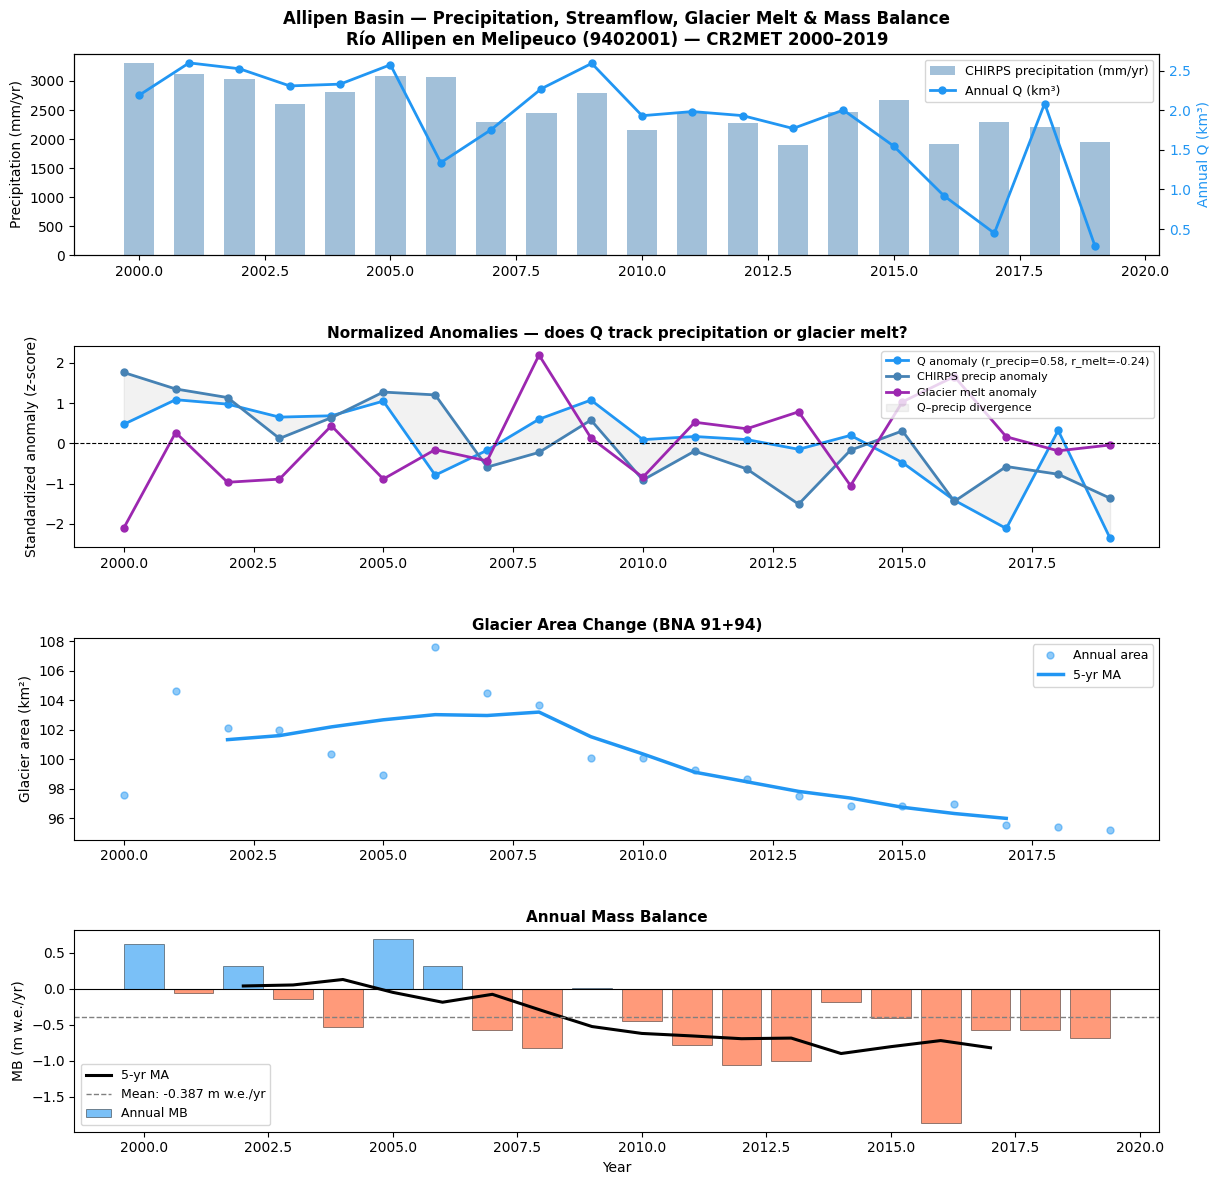

In [5]:
"""
Cell: Glacier area, MB, streamflow, and precipitation comparison
      Shows how Q variability relates to precip vs glacier loss
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

CAMELS_DIR = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001'

# ── Load streamflow ───────────────────────────────────────────────────────
q_raw = pd.read_csv(f'{CAMELS_DIR}/q_m3s_mon.csv')
q_raw['date'] = pd.to_datetime(q_raw['date'])
q_raw = q_raw.set_index('date')
q_m3_month = (q_raw['9402001'] * q_raw['9402001'].index.days_in_month * 86400).dropna()
q_annual = q_m3_month.resample('YE').sum()
q_annual.index = q_annual.index.year
q_annual = q_annual.loc[2000:2019]

# ── Load CHIRPS precipitation ─────────────────────────────────────────────
p_raw = pd.read_csv(f'{CAMELS_DIR}/precip_chirps_mon.csv')
p_raw['date'] = pd.to_datetime(p_raw['date'])
p_raw = p_raw.set_index('date')
p_ann = p_raw['9402001'].resample('YE').sum()
p_ann.index = p_ann.index.year
p_ann = p_ann.loc[2000:2019]
print(f'✓ CHIRPS precip loaded: mean = {p_ann.mean():.1f} mm/yr')

# ── Glacier data ──────────────────────────────────────────────────────────
melt_allipen   = out_91['melt_monthly'] + out_94['melt_monthly']
melt_ann       = melt_allipen.resample('YE').sum()
melt_ann.index = melt_ann.index.year
melt_ann       = melt_ann.loc[2000:2019]

area_ann = ((out_91['area_series'] + out_94['area_series']) / 1e6).loc[2000:2019]
mb_ann   = mb_allipen.loc[2000:2019]

# ── Normalize to z-scores for anomaly comparison ──────────────────────────
def zscore(s):
    return (s - s.mean()) / s.std()

# ── Correlations ──────────────────────────────────────────────────────────
print('\nCorrelations with annual Q (2000–2019):')
print(f'  CHIRPS precip:  r = {q_annual.corr(p_ann):.3f}')
print(f'  Glacier melt:   r = {q_annual.corr(melt_ann):.3f}')
print(f'  Glacier area:   r = {q_annual.corr(area_ann):.3f}')
print(f'  Glacier MB:     r = {q_annual.corr(mb_ann.reindex(q_annual.index)):.3f}')

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.45)

# ── Panel 1: Annual Q and precipitation ───────────────────────────────────
ax1  = fig.add_subplot(gs[0])
ax1b = ax1.twinx()

ax1.bar(p_ann.index, p_ann.values, color='steelblue', alpha=0.5,
        width=0.6, label='CHIRPS precipitation (mm/yr)')
ax1b.plot(q_annual.index, q_annual.values / 1e9, '-o',
          color=C_Q, linewidth=2, markersize=5, label='Annual Q (km³)')

ax1.set_ylabel('Precipitation (mm/yr)', fontsize=10)
ax1b.set_ylabel('Annual Q (km³)', fontsize=10, color=C_Q)
ax1b.tick_params(axis='y', labelcolor=C_Q)
ax1.set_title('Allipen Basin — Precipitation, Streamflow, Glacier Melt & Mass Balance\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9)

# ── Panel 2: Normalized anomalies — Q vs precip vs glacier melt ───────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(q_annual.index, zscore(q_annual), '-o',
         color=C_Q, linewidth=2, markersize=5,
         label=f'Q anomaly (r_precip={q_annual.corr(p_ann):.2f}, r_melt={q_annual.corr(melt_ann):.2f})')
ax2.plot(p_ann.index, zscore(p_ann), '-o',
         color='steelblue', linewidth=2, markersize=5,
         label='CHIRPS precip anomaly')
ax2.plot(melt_ann.index, zscore(melt_ann), '-o',
         color=C_MELT, linewidth=2, markersize=5,
         label='Glacier melt anomaly')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.fill_between(q_annual.index,
                 zscore(q_annual), zscore(p_ann),
                 alpha=0.1, color='gray',
                 label='Q–precip divergence')
ax2.set_ylabel('Standardized anomaly (z-score)', fontsize=10)
ax2.set_title('Normalized Anomalies — does Q track precipitation or glacier melt?',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)

# ── Panel 3: Glacier area ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
area_ma5 = pd.Series(area_ann.values, index=area_ann.index).rolling(5, center=True).mean()
ax3.plot(area_ann.index, area_ann.values, 'o',
         color=C_Q, markersize=5, alpha=0.5, label='Annual area')
ax3.plot(area_ann.index, area_ma5.values, '-',
         color=C_Q, linewidth=2.5, label='5-yr MA')
ax3.set_ylabel('Glacier area (km²)', fontsize=10)
ax3.set_title('Glacier Area Change (BNA 91+94)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)

# ── Panel 4: Annual MB ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3])
mb_ma5 = pd.Series(mb_ann.values, index=mb_ann.index).rolling(5, center=True).mean()
ax4.bar(mb_ann.index, mb_ann.values,
        color=[C_IMBAL if v < 0 else C_Q for v in mb_ann.values],
        alpha=0.6, edgecolor='black', linewidth=0.5, label='Annual MB')
ax4.plot(mb_ann.index, mb_ma5.values, '-', color='black',
         linewidth=2.2, label='5-yr MA')
ax4.axhline(0, color='black', linewidth=0.8)
ax4.axhline(mb_ann.mean(), color='gray', linewidth=1, linestyle='--',
            label=f'Mean: {mb_ann.mean():.3f} m w.e./yr')
ax4.set_ylabel('MB (m w.e./yr)', fontsize=10)
ax4.set_xlabel('Year', fontsize=10)
ax4.set_title('Annual Mass Balance', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)

plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_precip_Q_glacier.png',
            dpi=300, bbox_inches='tight')
plt.show()

## compare influence of precip change vs glacier change on streamflow

The correlations make sense — precip dominates Q (r=0.58) and glacier melt is weakly negative (glaciers melt more in dry years when Q is low, confirming the buffering story). Let's try a multiple regression with precip + MB together:

Correlation Q ~ Precip:      r = 0.579
Correlation Q ~ MB:          r = 0.471
Correlation Q ~ Precip+MB:   (see R² below)

Multiple regression: Q ~ Precip + Glacier MB
  R²:                0.336
  Precip coefficient (standardized):  0.416
  MB coefficient (standardized):      -0.044
  Intercept:         1.871 km³

  → Precip explains ~99% of the combined explained variance
  → MB explains     ~1% of the combined explained variance


/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_76359/2728681554.py:64: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1].plot(common, Q_pred, '-o', color='black', linewidth=2, markersize=5,


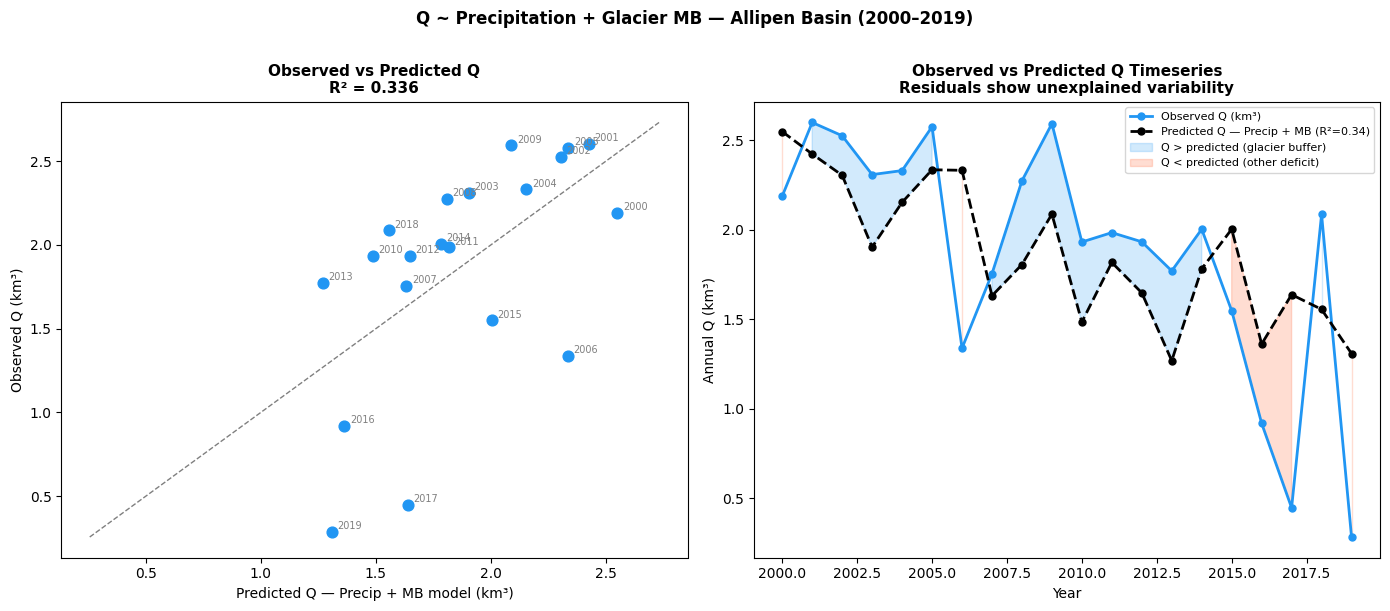

In [8]:
"""
Cell: Q ~ Precip + Glacier MB multiple regression
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ── Align all series ──────────────────────────────────────────────────────
common = q_annual.index\
    .intersection(p_ann.index)\
    .intersection(mb_ann.dropna().index)
common = common[(common >= 2000) & (common <= 2019)]

Q  = q_annual.loc[common].values / 1e9     # km³
P  = p_ann.loc[common].values              # mm/yr
MB = mb_ann.loc[common].values             # m w.e./yr

# ── Simple correlations ───────────────────────────────────────────────────
r_p,  _ = pd.Series(Q).corr(pd.Series(P)),  None
r_mb, _ = pd.Series(Q).corr(pd.Series(MB)), None
print(f'Correlation Q ~ Precip:      r = {pd.Series(Q).corr(pd.Series(P)):.3f}')
print(f'Correlation Q ~ MB:          r = {pd.Series(Q).corr(pd.Series(MB)):.3f}')
print(f'Correlation Q ~ Precip+MB:   (see R² below)')

# ── Multiple regression: Q ~ Precip + MB ─────────────────────────────────
X = np.column_stack([P, MB])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression().fit(X_scaled, Q)
Q_pred = model.predict(X_scaled)
ss_res = np.sum((Q - Q_pred)**2)
ss_tot = np.sum((Q - Q.mean())**2)
r2 = 1 - ss_res / ss_tot

print(f'\nMultiple regression: Q ~ Precip + Glacier MB')
print(f'  R²:                {r2:.3f}')
print(f'  Precip coefficient (standardized):  {model.coef_[0]:.3f}')
print(f'  MB coefficient (standardized):      {model.coef_[1]:.3f}')
print(f'  Intercept:         {model.intercept_:.3f} km³')
print(f'\n  → Precip explains ~{model.coef_[0]**2 / (model.coef_[0]**2 + model.coef_[1]**2) * 100:.0f}% of the combined explained variance')
print(f'  → MB explains     ~{model.coef_[1]**2 / (model.coef_[0]**2 + model.coef_[1]**2) * 100:.0f}% of the combined explained variance')

# ── Plot: Q vs Precip+MB predicted ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Observed vs predicted Q
axes[0].scatter(Q_pred, Q, color=C_Q, s=60, zorder=3)
for i, yr in enumerate(common):
    axes[0].annotate(str(yr), (Q_pred[i], Q[i]), fontsize=7,
                     xytext=(4, 2), textcoords='offset points', color='gray')
lims = [min(Q.min(), Q_pred.min()) * 0.9, max(Q.max(), Q_pred.max()) * 1.05]
axes[0].plot(lims, lims, '--', color='black', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Predicted Q — Precip + MB model (km³)', fontsize=10)
axes[0].set_ylabel('Observed Q (km³)', fontsize=10)
axes[0].set_title(f'Observed vs Predicted Q\nR² = {r2:.3f}', fontsize=11, fontweight='bold')

# Panel 2: Timeseries — observed vs predicted + anomaly decomposition
axes[1].plot(common, Q,      '-o', color=C_Q,    linewidth=2, markersize=5, label='Observed Q (km³)')
axes[1].plot(common, Q_pred, '-o', color='black', linewidth=2, markersize=5,
             linestyle='--', label=f'Predicted Q — Precip + MB (R²={r2:.2f})')

# Shade residuals
axes[1].fill_between(common, Q, Q_pred,
                     where=(Q > Q_pred), alpha=0.2, color=C_Q,
                     label='Q > predicted (glacier buffer)')
axes[1].fill_between(common, Q, Q_pred,
                     where=(Q < Q_pred), alpha=0.2, color=C_IMBAL,
                     label='Q < predicted (other deficit)')
axes[1].set_ylabel('Annual Q (km³)', fontsize=10)
axes[1].set_xlabel('Year', fontsize=10)
axes[1].set_title('Observed vs Predicted Q Timeseries\nResiduals show unexplained variability',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Q ~ Precipitation + Glacier MB — Allipen Basin (2000–2019)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_regression.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print(f'Correlation Precip ~ MB: r = {pd.Series(P).corr(pd.Series(MB)):.3f}')

Correlation Precip ~ MB: r = 0.847


## ahhh intersting, glacier MB in the Allipen is primarily precipitation-driven, not temperature-driven

In [13]:
"""
Cell: Climate drivers of glacier MB and streamflow — all seasons
      Reports r, r², and p-value for each relationship
"""

import pandas as pd
import numpy as np
from scipy.stats import pearsonr

CAMELS_DIR = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001'

# ── Load temperature (CR2MET) ─────────────────────────────────────────────
tmax = pd.read_csv(f'{CAMELS_DIR}/tmax_cr2met_mon.csv')
tmin = pd.read_csv(f'{CAMELS_DIR}/tmin_cr2met_mon.csv')
tmax['date'] = pd.to_datetime(tmax['date'])
tmin['date'] = pd.to_datetime(tmin['date'])
tmax = tmax.set_index('date')
tmin = tmin.set_index('date')
tmean_mon = (tmax['9402001'] + tmin['9402001']) / 2

t_ann = tmean_mon.resample('YE').mean()
t_ann.index = t_ann.index.year
t_ann = t_ann.loc[2000:2019]
print(f'✓ Temperature loaded: mean = {t_ann.mean():.2f} °C/yr')

# ── All seasonal temperatures & precipitation ─────────────────────────────
seasons_months = {
    'DJF (summer)': [12, 1, 2],
    'MAM (fall)':   [3, 4, 5],
    'JJA (winter)': [6, 7, 8],
    'SON (spring)': [9, 10, 11],
}

t_seas = {}
p_seas = {}
p_mon  = p_raw['9402001']

for name, months in seasons_months.items():
    t_s = tmean_mon[tmean_mon.index.month.isin(months)].resample('YE').mean()
    t_s.index = t_s.index.year
    t_seas[name] = t_s.loc[2000:2019]

    p_s = p_mon[p_mon.index.month.isin(months)].resample('YE').sum()
    p_s.index = p_s.index.year
    p_seas[name] = p_s.loc[2000:2019]

# ── Align all series ──────────────────────────────────────────────────────
common = q_annual.index\
    .intersection(p_ann.index)\
    .intersection(mb_ann.dropna().index)\
    .intersection(t_ann.index)
common = common[(common >= 2000) & (common <= 2019)]

Q  = q_annual.loc[common]
P  = p_ann.loc[common]
MB = mb_ann.loc[common]
T  = t_ann.loc[common]
M  = melt_ann.loc[common]

# ── Helper: compute r, r², p ──────────────────────────────────────────────
def correlate(x, y):
    idx = x.dropna().index.intersection(y.dropna().index)
    if len(idx) < 4:
        return np.nan, np.nan, np.nan
    r, p = pearsonr(x.loc[idx], y.loc[idx])
    return r, r**2, p

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return ''

def print_row(label, x, y):
    r, r2, p = correlate(x, y)
    stars = sig_stars(p)
    print(f'  {label:<34} r={r:>6.3f}  r²={r2:>5.3f}  p={p:>6.3f} {stars}')

# ── Full correlation table ────────────────────────────────────────────────
print('\n' + '='*75)
print('CORRELATION MATRIX — Allipen Basin 2000–2019')
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  . p<0.10')
print('='*75)

print('\n── Annual drivers ───────────────────────────────────────────────')
print_row('Precip (annual) → MB',   P,  MB)
print_row('Temp (annual) → MB',     T,  MB)
print_row('Precip (annual) → Q',    P,  Q)
print_row('Temp (annual) → Q',      T,  Q)
print_row('Glacier melt → Q',       M,  Q)
print_row('MB → Q',                 MB, Q)
print_row('Precip → Temp (annual)', P,  T)

print('\n── Seasonal temperature → MB ────────────────────────────────────')
for name in seasons_months:
    print_row(f'Temp {name:<16} → MB', t_seas[name].loc[common], MB)

print('\n── Seasonal temperature → Q ─────────────────────────────────────')
for name in seasons_months:
    print_row(f'Temp {name:<16} → Q',  t_seas[name].loc[common], Q)

print('\n── Seasonal precipitation → MB ──────────────────────────────────')
for name in seasons_months:
    print_row(f'Precip {name:<14} → MB', p_seas[name].loc[common], MB)

print('\n── Seasonal precipitation → Q ───────────────────────────────────')
for name in seasons_months:
    print_row(f'Precip {name:<14} → Q',  p_seas[name].loc[common], Q)

print('\n── Seasonal precip → seasonal temp ──────────────────────────────')
for name in seasons_months:
    print_row(f'Precip {name:<14} → Temp', p_seas[name].loc[common], t_seas[name].loc[common])

print('='*75)

✓ Temperature loaded: mean = 7.46 °C/yr

CORRELATION MATRIX — Allipen Basin 2000–2019
Significance: *** p<0.001  ** p<0.01  * p<0.05  . p<0.10

── Annual drivers ───────────────────────────────────────────────
  Precip (annual) → MB               r= 0.847  r²=0.717  p= 0.000 ***
  Temp (annual) → MB                 r=-0.672  r²=0.451  p= 0.001 **
  Precip (annual) → Q                r= 0.579  r²=0.335  p= 0.008 **
  Temp (annual) → Q                  r=-0.302  r²=0.091  p= 0.196 
  Glacier melt → Q                   r=-0.244  r²=0.060  p= 0.300 
  MB → Q                             r= 0.471  r²=0.222  p= 0.036 *
  Precip → Temp (annual)             r=-0.402  r²=0.162  p= 0.079 .

── Seasonal temperature → MB ────────────────────────────────────
  Temp DJF (summer)     → MB         r=-0.389  r²=0.151  p= 0.090 .
  Temp MAM (fall)       → MB         r=-0.472  r²=0.222  p= 0.036 *
  Temp JJA (winter)     → MB         r=-0.131  r²=0.017  p= 0.583 
  Temp SON (spring)     → MB         r=-0.

* Precipitation is the dominant and statistically strongest control on glacier MB, explaining 72% of its variance (r²=0.717, p<0.001). 
* Fall (MAM) precipitation is by far the strongest and most significant control on Q, explaining 49% of its variance (r²=0.493, p=0.001) — stronger than even annual precipitation (r²=0.335, p=0.008). 
* winter (JJA), spring (SON), and fall (MAM) precipitation all show significant positive relationships with MB (r²=0.39, 0.40, 0.34 respectively, all p<0.01), confirming that cold-season snowfall drives glacier health in this basin.
* glacier melt signal in streamflow is much smaller than the precip signal -- high precip years --> high streamflow years. not necessarily true for big glacier melt years --> big streamflow years
* Annual temperature is a significant secondary control on MB (r²=0.451, p=0.001), with spring (SON) being the most important season (r²=0.357, p=0.005). This makes physical sense — spring warming controls the onset of the melt season and determines how much of the winter snowpack survives into summer. Notably, winter temperature (JJA) has no significant relationship with MB (r²=0.017, p=0.583), meaning it is not cold winters that matter but warm springs that drive mass loss.

Melt timing trends (2000–2019):
  Peak melt month:        -0.147 months/yr  (p=0.112)
  50% cumulative melt:    +0.019 months/yr  (p=0.287)

  Peak melt month range:  1 – 12
  Most common peak month: 2


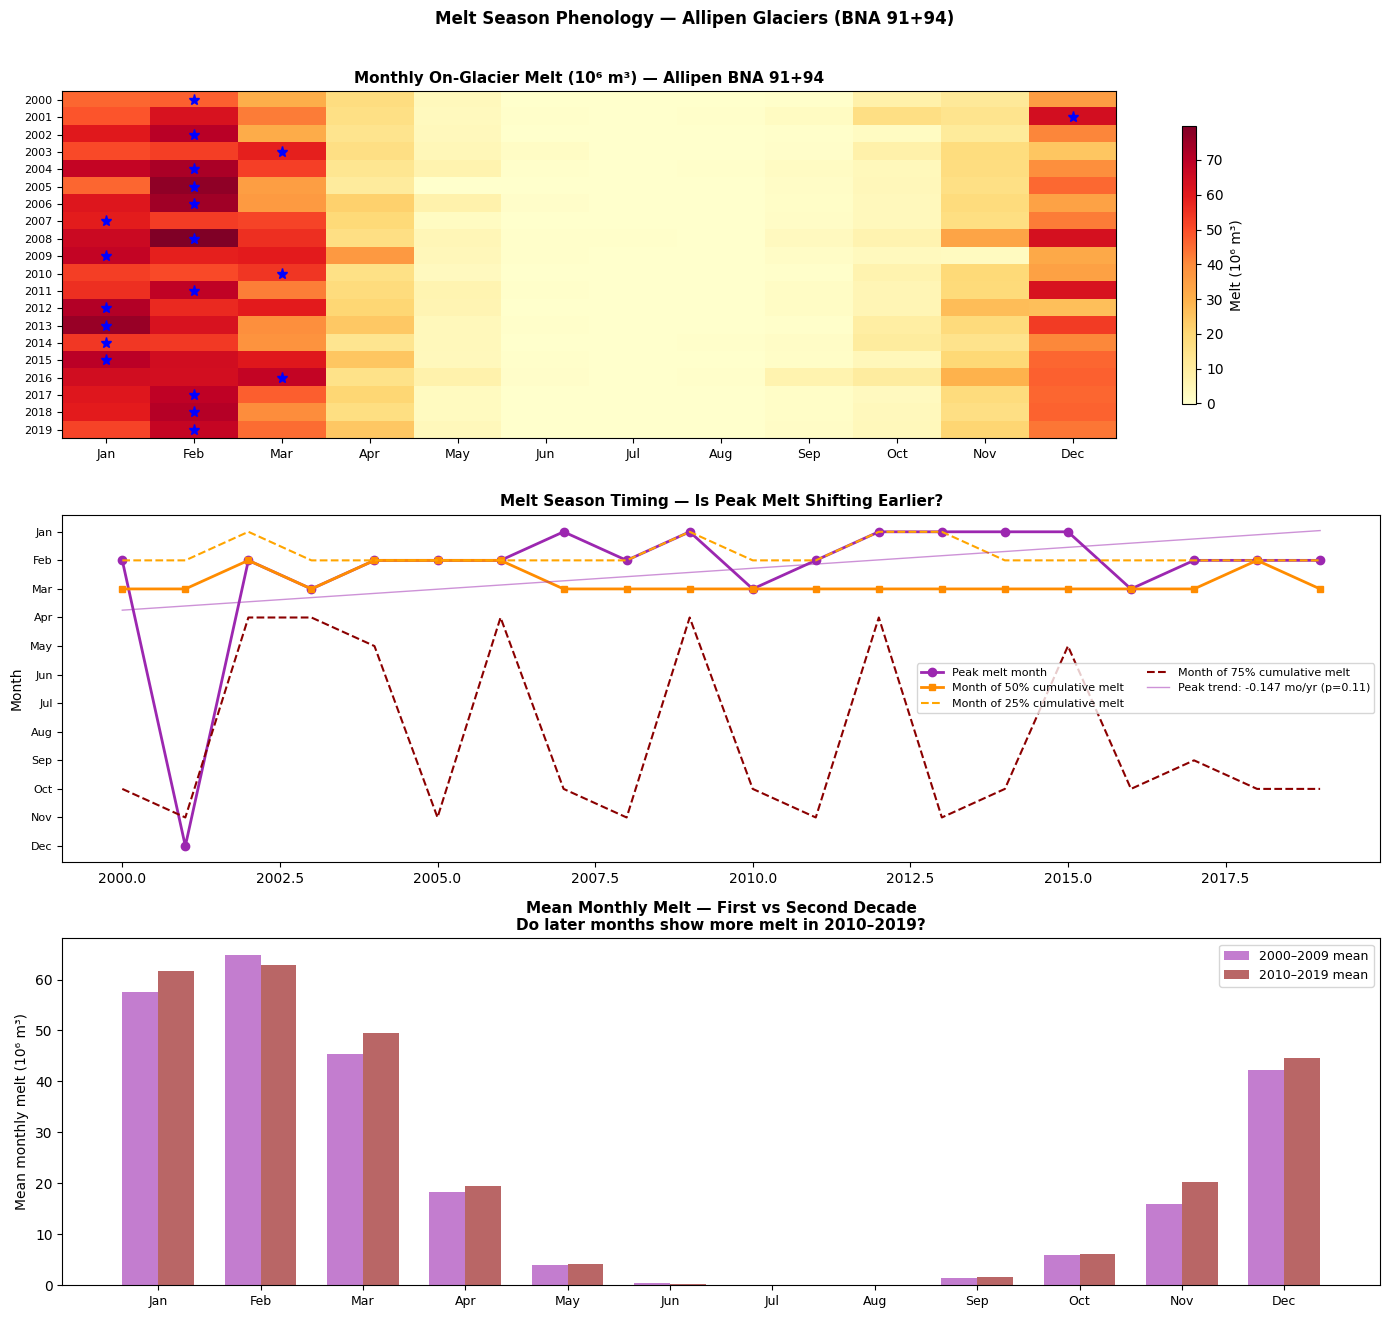

In [18]:
"""
Cell: Phenology analysis — is melt shifting earlier, accumulation later?
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ── Monthly melt by year ──────────────────────────────────────────────────
melt_allipen = out_91['melt_monthly'] + out_94['melt_monthly']
melt_2d = melt_allipen.loc['2000':'2019']

# Build year × month matrix
melt_mat = pd.DataFrame(
    {yr: melt_2d[melt_2d.index.year == yr].values
     for yr in range(2000, 2020)},
    index=range(1, 13)
).T  # shape (20 years × 12 months)
melt_mat.index = range(2000, 2020)
melt_mat.columns = range(1, 13)

# ── Month of peak melt each year ──────────────────────────────────────────
peak_melt_month = melt_mat.idxmax(axis=1)

# ── Cumulative melt timing — month when 25%, 50%, 75% of annual melt reached
def cum_threshold_month(row, threshold):
    cumsum = row.cumsum()
    total  = row.sum()
    if total == 0:
        return np.nan
    exceeded = cumsum[cumsum >= threshold * total]
    return exceeded.index[0] if len(exceeded) > 0 else np.nan

melt_25 = melt_mat.apply(cum_threshold_month, axis=1, threshold=0.25)
melt_50 = melt_mat.apply(cum_threshold_month, axis=1, threshold=0.50)
melt_75 = melt_mat.apply(cum_threshold_month, axis=1, threshold=0.75)

# ── Monthly MB by year ────────────────────────────────────────────────────
# Use mb_mwe_ann from out_91/94 — but we need monthly MB
# Approximate from vol_series monthly interpolation isn't available
# Instead use melt - accumulation proxy: look at net monthly melt sign
# We'll use the melt series itself and flag high vs low melt months

# ── Trends in melt timing ─────────────────────────────────────────────────
years = np.array(range(2000, 2020), dtype=float)

slope_peak, _, _, p_peak, _ = linregress(years, peak_melt_month.values)
slope_50,   _, _, p_50,   _ = linregress(years, melt_50.values)

print('Melt timing trends (2000–2019):')
print(f'  Peak melt month:        {slope_peak:+.3f} months/yr  (p={p_peak:.3f})')
print(f'  50% cumulative melt:    {slope_50:+.3f} months/yr  (p={p_50:.3f})')
print(f'\n  Peak melt month range:  {peak_melt_month.min()} – {peak_melt_month.max()}')
print(f'  Most common peak month: {peak_melt_month.mode()[0]}')

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Plot 1: Heatmap of monthly melt by year ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

im = axes[0].imshow(melt_mat.values / 1e6, aspect='auto',
                     cmap='YlOrRd', interpolation='nearest')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(MONTH_NAMES, fontsize=9)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(range(2000, 2020), fontsize=8)
axes[0].set_title('Monthly On-Glacier Melt (10⁶ m³) — Allipen BNA 91+94',
                  fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Melt (10⁶ m³)', shrink=0.8)

# Overlay peak melt month
for yr_idx, peak_m in enumerate(peak_melt_month.values):
    axes[0].plot(peak_m - 1, yr_idx, 'b*', markersize=8)

# ── Plot 2: Peak melt month over time ────────────────────────────────────
axes[1].plot(years, peak_melt_month.values, '-o',
             color=C_MELT, linewidth=2, markersize=6, label='Peak melt month')
axes[1].plot(years, melt_50.values, '-s',
             color='darkorange', linewidth=2, markersize=5, label='Month of 50% cumulative melt')
axes[1].plot(years, melt_25.values, '--',
             color='orange', linewidth=1.5, markersize=4, label='Month of 25% cumulative melt')
axes[1].plot(years, melt_75.values, '--',
             color='darkred', linewidth=1.5, markersize=4, label='Month of 75% cumulative melt')

# Trend line for peak
trend_peak = slope_peak * years + (peak_melt_month.mean() - slope_peak * years.mean())
axes[1].plot(years, trend_peak, '-', color=C_MELT, linewidth=1, alpha=0.5,
             label=f'Peak trend: {slope_peak:+.3f} mo/yr (p={p_peak:.2f})')

axes[1].set_yticks(range(1, 13))
axes[1].set_yticklabels(MONTH_NAMES, fontsize=8)
axes[1].set_ylabel('Month', fontsize=10)
axes[1].set_title('Melt Season Timing — Is Peak Melt Shifting Earlier?',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)
axes[1].invert_yaxis()  # Jan at top so earlier = up

# ── Plot 3: Mean monthly melt — first vs second decade ───────────────────
decade1 = melt_mat.loc[2000:2009].mean()
decade2 = melt_mat.loc[2010:2019].mean()

x = np.arange(1, 13)
w = 0.35
axes[2].bar(x - w/2, decade1.values / 1e6, width=w, color=C_MELT,
            alpha=0.6, label='2000–2009 mean')
axes[2].bar(x + w/2, decade2.values / 1e6, width=w, color='darkred',
            alpha=0.6, label='2010–2019 mean')
axes[2].set_xticks(x)
axes[2].set_xticklabels(MONTH_NAMES, fontsize=9)
axes[2].set_ylabel('Mean monthly melt (10⁶ m³)', fontsize=10)
axes[2].set_title('Mean Monthly Melt — First vs Second Decade\n'
                  'Do later months show more melt in 2010–2019?',
                  fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Melt Season Phenology — Allipen Glaciers (BNA 91+94)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_melt_phenology.png',
            dpi=300, bbox_inches='tight')
plt.show()

## hmm... melt is increasing in absolute terms across all months in the second decade, with no detectable shift in timing yet
* no clear signal whether spring pulses are shifting earlier or accumulation onset later 

In [19]:
# Compare melt vs rain on glacier for WA1
nc = nc_datasets['WA1']
years = nc['time'].values.astype(int)
valid = (years >= 2000) & (years <= 2019)

melt_total_gt  = np.nansum(nc['melt_on_glacier_monthly'].values[valid],  axis=(1,2)) / 1e12
rain_total_gt  = np.nansum(nc['liq_prcp_on_glacier_monthly'].values[valid], axis=(1,2)) / 1e12
snow_total_gt  = np.nansum(nc['snowfall_on_glacier_monthly'].values[valid], axis=(1,2)) / 1e12

print(f'WA1 mean annual (2000-2019):')
print(f'  Melt on glacier:  {melt_total_gt.mean():.3f} Gt/yr')
print(f'  Rain on glacier:  {rain_total_gt.mean():.3f} Gt/yr')
print(f'  Snow on glacier:  {snow_total_gt.mean():.3f} Gt/yr')
print(f'  Rain / Melt ratio: {rain_total_gt.mean() / melt_total_gt.mean():.2f}')
print(f'  Total runoff (melt+rain): {(melt_total_gt + rain_total_gt).mean():.3f} Gt/yr')

WA1 mean annual (2000-2019):
  Melt on glacier:  0.732 Gt/yr
  Rain on glacier:  0.332 Gt/yr
  Snow on glacier:  0.616 Gt/yr
  Rain / Melt ratio: 0.45
  Total runoff (melt+rain): 1.064 Gt/yr


## Ah, Ale suggests that I need to sum melt on glacier and precip on glacier to accurately compute glacier contributions to streamflow (before i was just considering glacier ablation). Here's some plots using his approach